# Regression Diagnostics Workflow — Real Data Walkthrough

**Dataset:** Auto MPG (real-world dataset of 1970s–80s car specs, commonly used for regression teaching)
**Goal:** predict `mpg` (fuel efficiency) from car specs like horsepower, weight, displacement, etc.

This notebook follows the **LINE + Multicollinearity** framework, in the order that actually
matters (not just a checklist — each step depends on the one before it):

1. Load & clean real data
2. Exploratory data analysis (EDA) — including a multicollinearity pre-check
3. Baseline linear regression
4. Residual diagnostics — the visual overview of all four LINE assumptions at once
5. **L**inearity — diagnose and fix (polynomial regression) — *must come first*, since a
   wrong functional form contaminates every diagnostic downstream
6. **Multicollinearity** — diagnose (VIF) and fix (Ridge / feature reduction) — re-checked
   here because Step 5's polynomial terms can *manufacture* new multicollinearity
7. **I**ndependence — diagnose (Durbin-Watson) — structural, not fixed by transformation
8. **N**ormality + **E**qual Variance — diagnosed and fixed *together*, since the same
   transformation (log) often resolves both at once
9. Bias-variance tradeoff via cross-validation & learning curves
10. Bias-variance decomposition via bootstrap
11. Final model comparison & takeaways

**Why this order, briefly:** Linearity comes first because residual patterns from a
mis-specified model shape look like other problems but aren't. Multicollinearity is
re-checked (not just checked once) because fixing linearity with polynomial terms can
introduce new collinearity. Independence is structural — it depends on how the data was
collected, not on any transformation. Normality and equal variance are grouped together
because they're so often fixed by the exact same trick (transforming the target).


## 0. Setup

Import everything we'll need. We'll use:
- `pandas` / `numpy` for data handling
- `matplotlib` for plots
- `scikit-learn` for models, splitting, and metrics
- `statsmodels` / `scipy` for formal statistical tests (Breusch-Pagan, Durbin-Watson,
  Shapiro-Wilk, Jarque-Bera, robust SEs, VIF)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.utils import resample

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.graphics.gofplots import qqplot
from scipy import stats as scipy_stats

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)
np.random.seed(42)


## 1. Load the Real Dataset

We're using the classic **Auto MPG** dataset — real specs for 398 cars from the 1970s-80s.
It's small enough to work with quickly, but has genuinely messy real-world properties:
missing values, correlated predictors (`displacement`, `horsepower`, `weight`, `cylinders` all
move together), and a nonlinear, heteroscedastic relationship between `horsepower` and `mpg`.

If you don't have internet access in your environment, download the CSV manually from the URL
below and load it locally instead.


In [4]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)
print(df.shape)
df.head()


(398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


### 1.1 Inspect data types and missing values

Real data is messy. Always check dtypes and missing values before doing anything else —
this dataset in particular has a few missing `horsepower` values encoded as NaN.


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [6]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


### 1.2 Clean the data

We'll drop rows with missing `horsepower` (only a handful) and drop `name` (a unique
identifier, not a useful predictor) and `origin` (categorical, not our focus — we'll keep
the model to numeric specs for this walkthrough).


In [7]:
df_clean = df.dropna(subset=['horsepower']).copy()
df_clean = df_clean.drop(columns=['name', 'origin'])
print(f"Rows before: {len(df)}, after dropping missing horsepower: {len(df_clean)}")
df_clean.describe()


Rows before: 398, after dropping missing horsepower: 392


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


## 2. Exploratory Data Analysis (EDA)

**Why this matters:** before fitting anything, we want to see (a) whether relationships
look linear or curved — foreshadowing the **Linearity** check — and (b) whether predictors
are correlated with each other — a **Multicollinearity pre-check**, doable before we ever
fit a model, since it only depends on the predictors (X), not on any residuals.

We'll work through this systematically: metadata and shape, then univariate statistics
(center, spread, shape) for each column, then bivariate statistics (relationships between
columns), and only then move to visual plots to confirm what the numbers are telling us.


### 2.1 Summary & Metadata (Data Structure)

Before looking at any individual statistic, get oriented: how big is the dataset, how much is
missing, and how many distinct values does each column take (cardinality — important for
telling continuous features apart from categorical/discrete ones, like `cylinders` here).


In [8]:
n_rows = len(df_clean)
print(f"Row count (n): {n_rows}")
print(f"Column count: {df_clean.shape[1]}")
print()

metadata = pd.DataFrame({
    'dtype': df_clean.dtypes,
    'missing_count': df_clean.isnull().sum(),
    'missing_pct': (df_clean.isnull().mean() * 100).round(2),
    'unique_count (cardinality)': df_clean.nunique()
})
metadata


Row count (n): 392
Column count: 7



,dtype,missing_count,missing_pct,unique_count (cardinality)
mpg,float64,0,0.0,127
cylinders,int64,0,0.0,5
displacement,float64,0,0.0,81
horsepower,float64,0,0.0,93
weight,int64,0,0.0,346
acceleration,float64,0,0.0,95
model_year,int64,0,0.0,13


**Reading this:** `model_year` and `cylinders` have low cardinality relative to the
other columns — they behave more like discrete/ordinal categories than continuous
measurements, which is worth keeping in mind when interpreting their distributions below.
Since we already cleaned missing values in Section 1.2, `missing_count` should be 0
everywhere here — this table is the general-purpose check to run *before* cleaning on any
new dataset.


### 2.2 Measures of Central Tendency (The Center)

- **Mean:** the arithmetic average — sensitive to outliers (a single huge value pulls it a lot)
- **Median:** the middle value when sorted — robust to outliers
- **Mode:** the most frequent value — most meaningful for discrete/categorical-like columns
- **Trimmed mean:** mean after cutting off the most extreme X% at each end — a middle ground
  between mean (uses everything, sensitive to outliers) and median (ignores everything except
  the middle point)

**Why compare mean vs. median:** a large gap between them is an early warning sign of skew —
if mean $\gg$ median, you likely have a right-skewed distribution with high-value outliers
pulling the average up (we'll confirm this formally with skewness in Section 2.4, and it
foreshadows the **Normality** check in Section 8).


In [9]:
numeric_cols = df_clean.columns.tolist()

central_tendency = pd.DataFrame({
    'mean': df_clean[numeric_cols].mean(),
    'median': df_clean[numeric_cols].median(),
    'mode': df_clean[numeric_cols].mode().iloc[0],
    'trimmed_mean_10pct': [scipy_stats.trim_mean(df_clean[c], 0.1) for c in numeric_cols],
})
central_tendency['mean_minus_median'] = central_tendency['mean'] - central_tendency['median']
central_tendency.round(2)


,mean,median,mode,trimmed_mean_10pct,mean_minus_median
mpg,23.45,22.75,13.0,22.99,0.70
cylinders,5.47,4.00,4.0,5.35,1.47
displacement,194.41,151.00,97.0,183.83,43.41
horsepower,104.47,93.50,150.0,99.82,10.97
weight,2977.58,2803.50,1985.0,2916.94,174.08
acceleration,15.54,15.50,14.5,15.48,0.04
model_year,75.98,76.00,73.0,75.97,-0.02


### 2.3 Measures of Dispersion & Spread (The Variability)

- **Min / Max / Range:** the extremes and the total spread between them
- **Variance / Standard deviation:** average squared/unsquared deviation from the mean —
  standard deviation is in the original units, so it's usually easier to interpret
- **Percentiles / Quartiles:** value cutoffs at specific ranks (e.g. Q1 = 25th percentile,
  Q3 = 75th percentile)
- **IQR (Q3 − Q1):** the spread of the middle 50% of the data — robust to outliers, often
  paired with the median the same way std is paired with the mean
- **Coefficient of Variation (CV = std / mean):** a *unitless* measure of relative spread,
  which lets you compare variability across columns that are on completely different scales
  (e.g. is `weight` or `acceleration` more variable *relative to its own typical size*?)


In [10]:
dispersion = pd.DataFrame({
    'min': df_clean[numeric_cols].min(),
    'max': df_clean[numeric_cols].max(),
    'range': df_clean[numeric_cols].max() - df_clean[numeric_cols].min(),
    'variance': df_clean[numeric_cols].var(),
    'std': df_clean[numeric_cols].std(),
    'Q1 (25th pct)': df_clean[numeric_cols].quantile(0.25),
    'Q3 (75th pct)': df_clean[numeric_cols].quantile(0.75),
})
dispersion['IQR'] = dispersion['Q3 (75th pct)'] - dispersion['Q1 (25th pct)']
dispersion['CV'] = (dispersion['std'] / df_clean[numeric_cols].mean()).round(3)
dispersion.round(2)


,min,max,range,variance,std,Q1 (25th pct),Q3 (75th pct),IQR,CV
mpg,9.0,46.6,37.6,60.92,7.81,17.00,29.00,12.00,0.33
cylinders,3.0,8.0,5.0,2.91,1.71,4.00,8.00,4.00,0.31
displacement,68.0,455.0,387.0,10950.37,104.64,105.00,275.75,170.75,0.54
horsepower,46.0,230.0,184.0,1481.57,38.49,75.00,126.00,51.00,0.37
weight,1613.0,5140.0,3527.0,721484.71,849.40,2225.25,3614.75,1389.50,0.28
acceleration,8.0,24.8,16.8,7.61,2.76,13.78,17.02,3.25,0.18
model_year,70.0,82.0,12.0,13.57,3.68,73.00,79.00,6.00,0.05


In [11]:
# Full percentile breakdown (10th, 25th, 50th, 75th, 90th) - a finer-grained view than quartiles alone
percentiles = df_clean[numeric_cols].quantile([0.10, 0.25, 0.50, 0.75, 0.90]).T
percentiles.columns = ['P10', 'P25 (Q1)', 'P50 (median)', 'P75 (Q3)', 'P90']
percentiles.round(2)


,P10,P25 (Q1),P50 (median),P75 (Q3),P90
mpg,14.0,17.00,22.75,29.00,34.19
cylinders,4.0,4.00,4.00,8.00,8.00
displacement,90.0,105.00,151.00,275.75,350.00
horsepower,67.0,75.00,93.50,126.00,157.70
weight,1990.0,2225.25,2803.50,3614.75,4277.60
acceleration,12.0,13.78,15.50,17.02,19.00
model_year,71.0,73.00,76.00,79.00,81.00


**Reading CV:** columns with a higher CV are more variable *relative to their own
scale*, even if their raw standard deviation looks small. This is the right way to compare
"which feature is more spread out" across columns measured in totally different units
(cars per cylinder count vs. pounds of weight vs. seconds of acceleration, for example).


### 2.4 Measures of Distribution Shape (The Behavior)

These are the 3rd and 4th moments — formalizing what histograms show visually, and a direct
preview of the formal **Normality** tests in Section 8:

- **Skewness:** asymmetry. Positive → right tail stretches out; negative → left tail
  stretches out; near 0 → roughly symmetric
- **Kurtosis (excess):** tail heaviness relative to a Normal distribution (pandas reports
  *excess* kurtosis, so Normal = 0 here, not 3)
  - **Leptokurtic** (kurtosis > 0): sharper peak, heavier tails — more outlier-prone than Normal
  - **Platykurtic** (kurtosis < 0): flatter peak, thinner tails — fewer extreme values than Normal


In [12]:
shape_stats = pd.DataFrame({
    'skewness': df_clean[numeric_cols].skew(),
    'kurtosis_excess': df_clean[numeric_cols].kurt()
})

def skew_label(s):
    if s > 0.5: return "right-skewed"
    elif s < -0.5: return "left-skewed"
    else: return "~symmetric"

def kurt_label(k):
    if k > 0.5: return "leptokurtic (heavy tails)"
    elif k < -0.5: return "platykurtic (light tails)"
    else: return "~normal tails"

shape_stats['skew_interpretation'] = shape_stats['skewness'].apply(skew_label)
shape_stats['kurtosis_interpretation'] = shape_stats['kurtosis_excess'].apply(kurt_label)
shape_stats.round(3)


,skewness,kurtosis_excess,skew_interpretation,kurtosis_interpretation
mpg,0.457,-0.516,~symmetric,platykurtic (light tails)
cylinders,0.508,-1.398,right-skewed,platykurtic (light tails)
displacement,0.702,-0.778,right-skewed,platykurtic (light tails)
horsepower,1.087,0.697,right-skewed,leptokurtic (heavy tails)
weight,0.520,-0.809,right-skewed,platykurtic (light tails)
acceleration,0.292,0.444,~symmetric,~normal tails
model_year,0.020,-1.167,~symmetric,platykurtic (light tails)


**Connecting this back to the workflow:** `mpg` itself typically comes out right-skewed
(more cars clustered at lower/moderate mpg, with a tail of a few very fuel-efficient cars) —
this is exactly the pattern that will motivate the log-transform fix for Normality AND Equal
Variance together in Section 8. Skewed predictors are also often the ones that show up as
curved (not straight) relationships in the scatter plots below — a Linearity preview too.


### 2.5 Measures of Relationship (Bivariate/Multivariate Statistics)

Before fitting any model, quantify how variables relate to each other:

- **Pearson correlation ($r$):** strength/direction of a **linear** relationship, range
  $[-1, 1]$
- **Spearman rank correlation:** strength/direction of a **monotonic** relationship (doesn't
  have to be linear — works off ranks instead of raw values, so it's more robust to outliers
  and curved-but-monotonic patterns)
- **Covariance:** direction of co-movement between two variables, but *not* standardized —
  it's on the product of the two variables' units, so magnitudes aren't comparable across
  variable pairs the way correlation is
- **Cross-tabulation + Chi-square:** for categorical variables, a contingency table of
  frequency counts, typically tested with a Chi-square test for independence


In [13]:
pearson_corr = df_clean[numeric_cols].corr(method='pearson')
spearman_corr = df_clean[numeric_cols].corr(method='spearman')

print("Pearson correlation with mpg (linear relationships):")
print(pearson_corr['mpg'].sort_values(ascending=True).round(3))
print()
print("Spearman correlation with mpg (monotonic relationships):")
print(spearman_corr['mpg'].sort_values(ascending=True).round(3))


Pearson correlation with mpg (linear relationships):
weight         -0.832
displacement   -0.805
horsepower     -0.778
cylinders      -0.778
acceleration    0.423
model_year      0.581
mpg             1.000
Name: mpg, dtype: float64

Spearman correlation with mpg (monotonic relationships):
weight         -0.876
displacement   -0.855
horsepower     -0.854
cylinders      -0.823
acceleration    0.442
model_year      0.575
mpg             1.000
Name: mpg, dtype: float64


**Pearson vs. Spearman comparison is itself a diagnostic:** if Spearman is noticeably
stronger (more negative/positive) than Pearson for a given feature, that's a sign the true
relationship is monotonic but *curved* rather than straight-line — Pearson under-credits it
because it only measures linear association. Watch `horsepower` and `weight` here; we already
know from Section 5 that `horsepower` vs. `mpg` is curved, so expect Spearman to pick up
slightly more of that relationship than Pearson does.


In [14]:
# Covariance matrix - same direction of relationship as correlation, but NOT standardized,
# so raw magnitudes aren't comparable across different variable pairs
cov_matrix = df_clean[numeric_cols].cov()
cov_matrix.round(1)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,60.9,-10.4,-657.6,-233.9,-5517.4,9.1,16.7
cylinders,-10.4,2.9,169.7,55.3,1300.4,-2.4,-2.2
displacement,-657.6,169.7,10950.4,3614.0,82929.1,-157.0,-142.6
horsepower,-233.9,55.3,3614.0,1481.6,28265.6,-73.2,-59.0
weight,-5517.4,1300.4,82929.1,28265.6,721484.7,-976.8,-967.2
acceleration,9.1,-2.4,-157.0,-73.2,-976.8,7.6,3.0
model_year,16.7,-2.2,-142.6,-59.0,-967.2,3.0,13.6


**Why correlation is usually preferred over covariance for comparison:** notice the
covariance between `weight` and `displacement` is a huge number, while covariance between
`acceleration` and `mpg` is tiny — but that's purely a units artifact (pounds × cubic inches
vs. seconds × mpg), not necessarily a difference in relationship *strength*. Correlation
divides out the scale, making the numbers comparable.


#### Cross-tabulation & Chi-square (categorical example)

Our modeling features are all numeric, but the original data has one categorical column —
`origin` (where the car was made) — that we dropped in Section 1.2. It's a good example of
when to reach for a cross-tab: checking whether `origin` and (discretized) `cylinders` are
independent, or whether certain cylinder counts cluster by origin.

**Note:** this is "independence" in the categorical-association sense (are two *variables*
related), which is a different concept from the **Independence** LINE assumption in Section 7
(are the *residuals* correlated with each other) — same word, two different things. Don't mix
them up.


In [15]:
# Rebuild a small frame with origin (from the original, uncleaned df) just for this example
origin_example = df[['cylinders', 'origin']].dropna()

contingency = pd.crosstab(origin_example['cylinders'], origin_example['origin'])
print("Contingency table: cylinders x origin")
print(contingency)
print()

chi2, chi2_pvalue, dof, expected = scipy_stats.chi2_contingency(contingency)
print(f"Chi-square statistic: {chi2:.2f}")
print(f"p-value: {chi2_pvalue:.6f}")
print(f"Degrees of freedom: {dof}")
if chi2_pvalue < 0.05:
    print("\n-> p < 0.05: cylinder count and origin are NOT independent -")
    print("   certain cylinder counts are strongly associated with certain regions")
    print("   (e.g. 4-cylinder engines were far more common outside the US in this era).")


Contingency table: cylinders x origin
origin     europe  japan  usa
cylinders                    
3               0      4    0
4              63     69   72
5               3      0    0
6               4      6   74
8               0      0  103

Chi-square statistic: 180.10
p-value: 0.000000
Degrees of freedom: 8

-> p < 0.05: cylinder count and origin are NOT independent -
   certain cylinder counts are strongly associated with certain regions
   (e.g. 4-cylinder engines were far more common outside the US in this era).


With the full statistical picture in hand — metadata, central tendency, spread, shape,
and relationships — we now move to the visual plots below to confirm these numbers match
what we can see directly.


### 2.6 Visual Relationships (Scatter Plots)


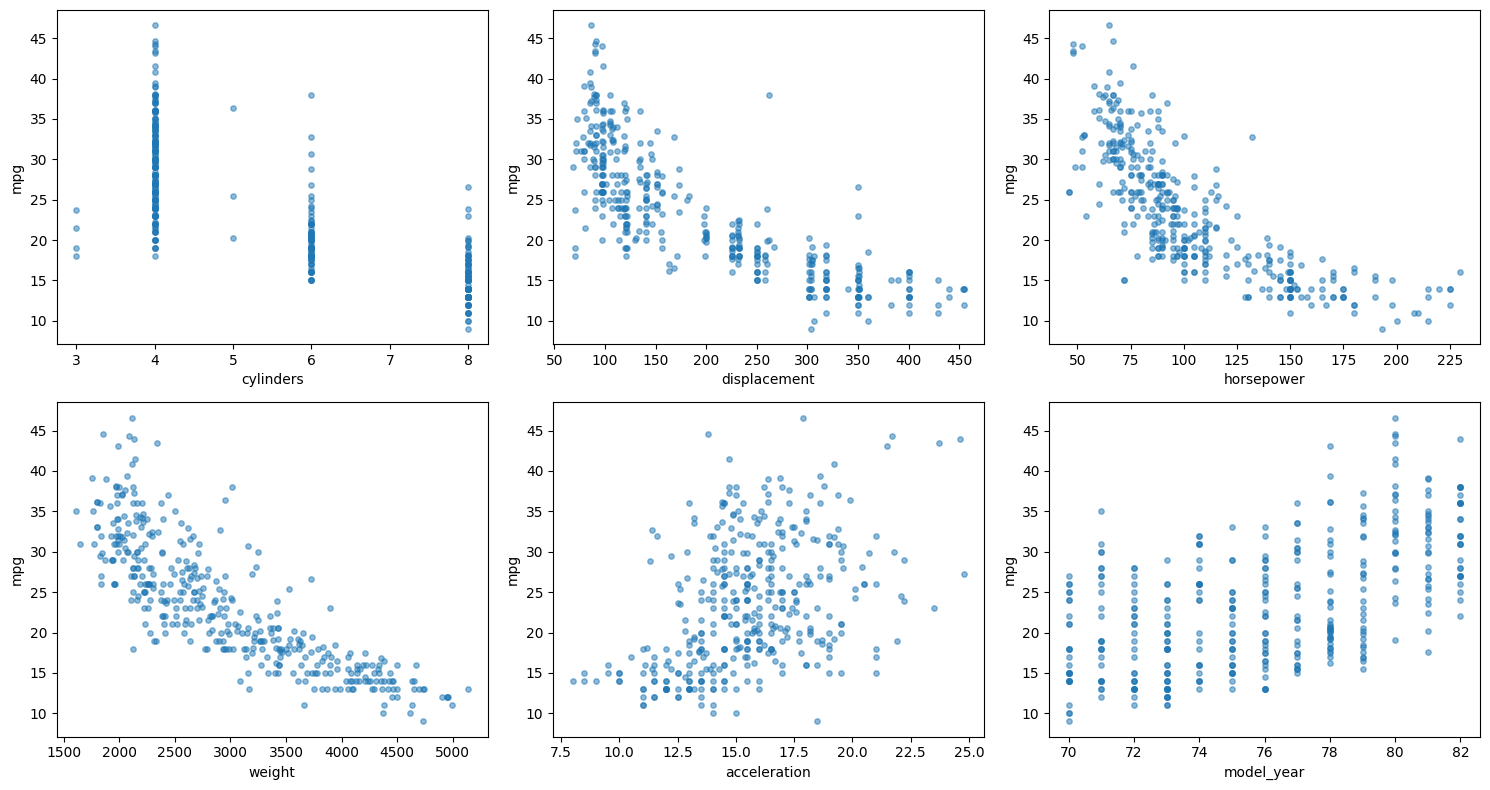

In [16]:
# Scatter of each predictor against the target
features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), features):
    ax.scatter(df_clean[feat], df_clean['mpg'], alpha=0.5, s=15)
    ax.set_xlabel(feat)
    ax.set_ylabel('mpg')
plt.tight_layout()
plt.show()


**What to look for:** `horsepower`, `displacement`, and `weight` all show a clear
**curved, not straight-line** relationship with `mpg` — mpg drops fast at first as these
increase, then levels off. That's a strong early signal for **Linearity** (Section 5) — we'll
need polynomial terms or a transformation, not just a straight line.


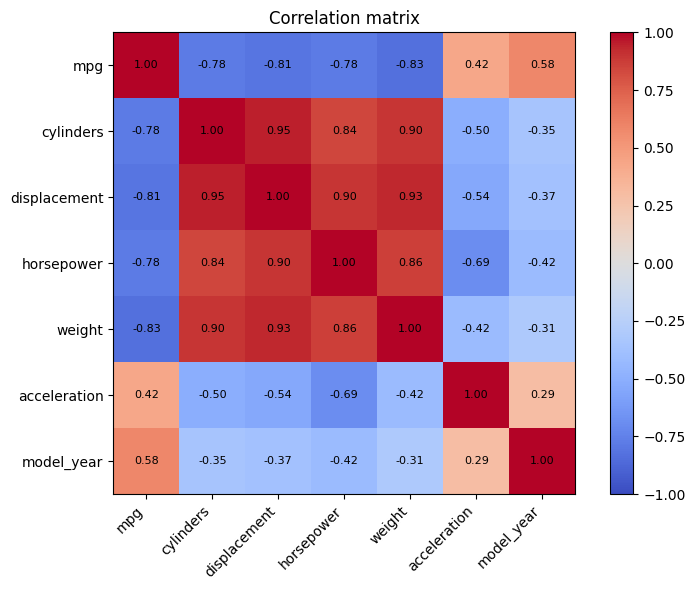

In [17]:
# Correlation matrix - flags multicollinearity risk before we even fit a model
corr = df_clean.corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)
plt.colorbar(im)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()


**Key observation:** `cylinders`, `displacement`, `horsepower`, and `weight` are all
correlated with each other at 0.85+ — these variables all essentially describe "how big and
powerful is the engine." This is a **Multicollinearity** pre-check (formalized with VIF in
Section 6): including all four in a linear model will make individual coefficients unstable,
even though the model's overall predictions may still be fine.


## 3. Baseline Linear Regression

We start simple, as the workflow prescribes: fit an ordinary linear regression on all
numeric predictors, then diagnose it before making any changes.

### The math: multiple linear regression

With $p$ predictors, the model assumes the target is a linear combination of the features
plus random noise:

$$
y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \dots + \beta_p x_{ip} + \varepsilon_i
$$

In matrix form, stacking all $n$ observations:

$$
\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}
$$

Ordinary Least Squares (OLS) finds the coefficients $\hat{\boldsymbol{\beta}}$ that minimize
the sum of squared residuals:

$$
\hat{\boldsymbol{\beta}} = \arg\min_{\boldsymbol{\beta}} \sum_{i=1}^n \left( y_i - \hat{y}_i \right)^2
= \arg\min_{\boldsymbol{\beta}} \lVert \mathbf{y} - \mathbf{X}\boldsymbol{\beta} \rVert^2
$$

This has a closed-form solution (the **normal equation**):

$$
\hat{\boldsymbol{\beta}} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}
$$

**Why this matters for the diagnostics ahead:** that matrix inverse
$(\mathbf{X}^\top \mathbf{X})^{-1}$ is exactly where multicollinearity causes trouble — if
columns of $\mathbf{X}$ are highly correlated, $\mathbf{X}^\top \mathbf{X}$ becomes close to
*singular* (non-invertible), and the inverse blows up, which is why coefficients become huge
and unstable (Section 6). OLS also assumes the noise term has **constant variance**,
$\text{Var}(\varepsilon_i) = \sigma^2$ for all $i$ — when that's violated, we get
heteroscedasticity (Section 8).


In [18]:
feature_cols = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
X = df_clean[feature_cols]
y = df_clean['mpg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

lin_model = LinearRegression().fit(X_train, y_train)

train_pred = lin_model.predict(X_train)
test_pred = lin_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print(f"Train RMSE: {train_rmse:.3f}")
print(f"Test RMSE:  {test_rmse:.3f}")
print(f"Test R^2:   {r2_score(y_test, test_pred):.3f}")
print()
coef_table = pd.DataFrame({'feature': feature_cols, 'coefficient': lin_model.coef_})
print(coef_table)
print()
print("Note: coefficients are on raw, unstandardized scales (e.g. weight is in\n"
      "      pounds, acceleration is in seconds) - magnitude alone is NOT a fair\n"
      "      comparison of feature importance across columns yet. Also, several\n"
      "      of these features are collinear (Section 6), so treat these estimates\n"
      "      as provisional until that's checked.")


Train RMSE: 3.491
Test RMSE:  3.185
Test R^2:   0.799

        feature  coefficient
0     cylinders    -0.160143
1  displacement     0.000373
2    horsepower    -0.001899
3        weight    -0.006457
4  acceleration     0.057588
5    model_year     0.762270

Note: coefficients are on raw, unstandardized scales (e.g. weight is in
      pounds, acceleration is in seconds) - magnitude alone is NOT a fair
      comparison of feature importance across columns yet. Also, several
      of these features are collinear (Section 6), so treat these estimates
      as provisional until that's checked.


Train and test RMSE being reasonably close suggests we're not wildly overfitting, but
that alone doesn't tell us if the model is well-specified. We need to look at the residuals.


## 4. Residual Diagnostics — The LINE Overview

**Why:** residuals are the raw material for detecting nearly every regression problem. This
section is a *visual overview* of all four LINE assumptions at once — Sections 5-8 then
formalize and fix each one individually, in the order that respects their dependencies.

### The math: residuals and the four assumptions they test

The residual for observation $i$ is simply the gap between what actually happened and what
the model predicted:

$$
e_i = y_i - \hat{y}_i
$$

OLS relies on four key assumptions about the true error term $\varepsilon_i$ (residuals
$e_i$ are our sample estimate of it) — this is exactly where the **LINE** acronym comes from:

$$
\mathbb{E}[\varepsilon_i \mid X] = 0 \quad \textbf{(L}\text{inearity — no systematic bias — Residuals vs Fitted)}
$$

$$
\text{Cov}(\varepsilon_i, \varepsilon_j) = 0 \text{ for } i \ne j \quad \textbf{(I}\text{ndependence — Section 7, Durbin-Watson)}
$$

$$
\varepsilon_i \sim \mathcal{N}(0, \sigma^2) \quad \textbf{(N}\text{ormality — Section 8, Q-Q plot / Shapiro-Wilk)}
$$

$$
\text{Var}(\varepsilon_i \mid X) = \sigma^2 \;\; \text{constant for all } i \quad \textbf{(E}\text{qual variance — Section 8, Breusch-Pagan)}
$$

If the first assumption fails, we have a **bias** problem (need more model flexibility). If
the last fails, we have **heteroscedasticity**. If the middle two fail, our p-values and
confidence intervals become unreliable even if coefficients are still unbiased.


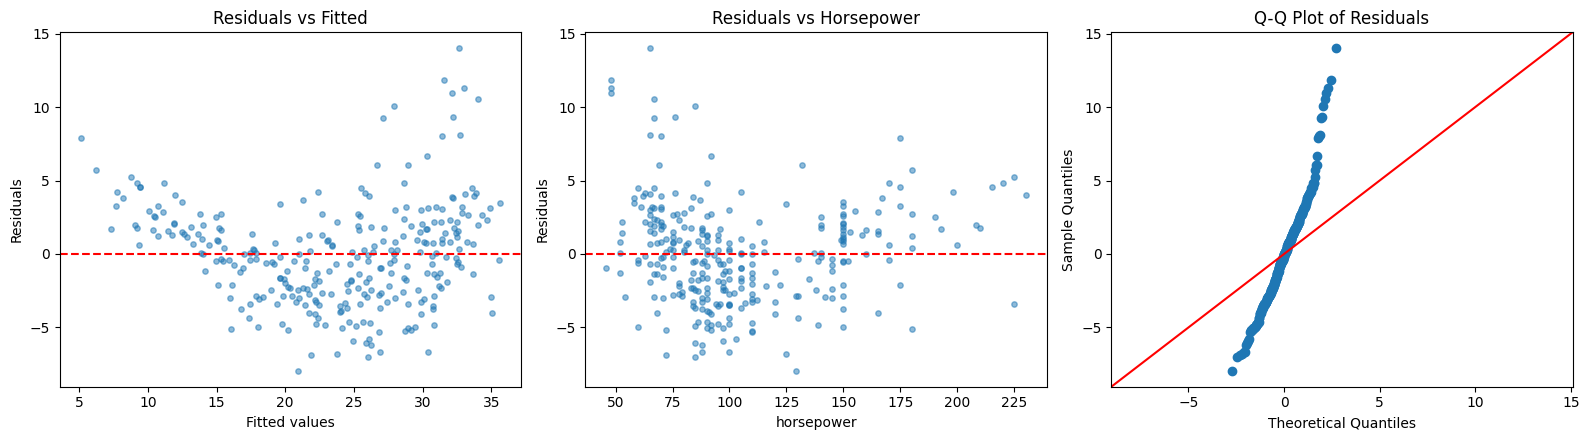

In [19]:
residuals = y_train - train_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) Residuals vs fitted - look for curve (Linearity) or funnel (Equal Variance)
axes[0].scatter(train_pred, residuals, alpha=0.5, s=15)
axes[0].axhline(0, color='red', ls='--')
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

# (b) Residuals vs a specific predictor known to be nonlinear
axes[1].scatter(X_train['horsepower'], residuals, alpha=0.5, s=15)
axes[1].axhline(0, color='red', ls='--')
axes[1].set_xlabel("horsepower")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Horsepower")

# (c) Q-Q plot - checks the Normality assumption
qqplot(residuals, line='45', ax=axes[2])
axes[2].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()


**Reading these plots (mapped to LINE):**
- **Residuals vs Fitted → Linearity:** if you see a bowl/arc shape rather than a random cloud,
  the model is systematically missing curvature — fixed in Section 5.
- **Residuals vs Horsepower → Equal Variance:** watch for a funnel — wider spread at one end
  than the other. Diagnosed formally and fixed in Section 8.
- **Q-Q Plot → Normality:** points hugging the diagonal line means residuals are roughly
  normal. Points curving away at the tails means non-normal residuals — diagnosed formally
  and fixed in Section 8, alongside Equal Variance.
- **Independence** doesn't show up in any of these three plots — it requires looking at
  residuals *in sequence*, which is what Section 7's Durbin-Watson test does.


### Quick Reference: LINE + Multicollinearity, One By One

Before diving into each fix in detail, here's the plain-language version of all five issues
side by side — what goes wrong, and how it's typically fixed. Each one gets its own full
section below with the actual code, math, and real results on this dataset.

**L — Linearity Violation**
- **The Problem:** the residual plot shows a clear pattern (a bowl/U-shape or S-curve),
  meaning a straight line is misrepresenting the real relationship between predictors and the
  target.
- **The Countermeasures:**
  - *Feature transformation:* add polynomial terms (e.g. a `horsepower²` column) or apply a
    transform like `log(x)` to the predictor.
  - *Switch models:* if the relationship is too jagged/complex for any reasonable polynomial,
    move to a tree-based model (Random Forest, XGBoost) that handles nonlinearity natively.

**Multicollinearity**
- **The Problem:** two or more predictors are highly correlated with each other, so the model
  can't isolate each one's individual effect — coefficients become unstable and swing wildly
  with small data changes.
- **The Countermeasures:**
  - *Drop or combine redundant features* (keep the one most relevant to the target, drop the
    rest).
  - *Ridge regression* — penalizes large coefficients, keeping all features but stabilizing
    the estimates.
  - *PCA* — replace correlated features with a smaller set of uncorrelated components (not
    used in this notebook, but a common alternative).

**I — Independence Violation**
- **The Problem:** residuals are correlated with each other (autocorrelation) instead of being
  independent — e.g. if you overestimate one observation, you're likely to overestimate the
  next one too.
- **The Countermeasures:**
  - *Add lag features* — if data is time-tracked, include the previous period's value as a
    predictor.
  - *Switch models* — use a Time Series model (ARIMA) or Generalized Least Squares (GLS),
    which mathematically account for correlated observations.
  - *Cluster-robust standard errors* — if the dependence comes from grouping (e.g. houses in
    the same neighborhood), recompute standard errors to account for within-group correlation.

**N — Normality Violation**
- **The Problem:** the Q-Q plot shows residuals don't follow a bell curve — usually because
  the target variable has heavy skew (a few extreme values pulling one tail out).
- **The Countermeasures:**
  - *Transform the target* — `log(y)` is the most common fix, pulling extreme high values
    closer to the average and straightening out the distribution.
  - *Box-Cox / Yeo-Johnson* — automated routines that search for the best exponent to make the
    target as Normal as possible (Yeo-Johnson also works with zero/negative values, unlike
    Box-Cox).

**E — Equal Variance (Homoscedasticity) Violation**
- **The Problem:** the residual plot looks like a funnel — the model is precise for some
  observations (e.g. cheap/common cases) and wildly off for others (e.g. expensive/rare
  cases).
- **The Countermeasures:**
  - *Transform the target* — `log(y)` conveniently often fixes this at the same time as
    Normality, by stabilizing the relative (not absolute) size of errors.
  - *Weighted Least Squares (WLS)* — explicitly tells the model to trust some observations
    more than others, based on their known variance.
  - *Robust standard errors* — leaves the fitted line unchanged, but recalculates standard
    errors/p-values so conclusions stay valid despite the uneven variance.

**Why N and E are covered together in Section 8:** in practice the exact same fix (`log(y)`)
very often resolves both at once, which is exactly what we'll see happen with real numbers
below.


## 5. L — Linearity

**The Problem:** the residual plot shows a clear pattern (like a bowl/U-shape or an S-curve),
meaning a straight line is misrepresenting the real relationship. We already saw this directly
in Section 4 — the "Residuals vs Horsepower" panel shows a bowing pattern, not a random cloud.

**The Countermeasures:**
- **Feature transformation:** turn the linear feature into a nonlinear one — add polynomial
  terms (`horsepower²`, `horsepower³`, ...) or apply a transform like `log(x)`. This is what
  we do below.
- **Switch models:** if the relationship is too jagged or complex for any reasonable
  polynomial degree, move away from linear regression entirely to a tree-based model (Random
  Forest, XGBoost), which handles nonlinear relationships natively without any of this feature
  engineering.

**This comes first, deliberately.** If the functional form is wrong, residual patterns from
*every other* diagnostic downstream become unreliable — a curved residual pattern isn't
"heteroscedasticity," it's bias from the wrong model shape. Fix this before trusting any other
test.

We saw curvature in the `horsepower`-`mpg` relationship in Section 2 and a bowl-shaped
residual pattern in Section 4 — a classic underfitting/bias signal for a purely linear model.
Let's use `horsepower` alone to clearly illustrate the linear vs. polynomial tradeoff, the
same way we would with any single nonlinear predictor.

### The math: polynomial regression is still linear regression

Polynomial regression fits a curve by adding powers of $x$ as new features:

$$
y_i = \beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \dots + \beta_d x_i^d + \varepsilon_i
$$

This looks nonlinear in $x$, but it's still **linear in the parameters** $\beta_j$ — so it's
solved with exactly the same normal equation from Section 3, just with an expanded feature
matrix $[\,1,\ x,\ x^2,\ \dots,\ x^d\,]$. That's also precisely why raw polynomial terms
create severe multicollinearity: $x$, $x^2$, $x^3$... are mechanically correlated with each
other by construction — this is the **same VIF problem covered formally in Section 6**,
self-inflicted by feature engineering rather than by the raw data. We'll verify this directly
below, right after fitting the polynomial model.

The degree $d$ directly controls model flexibility — and therefore where you land on the
bias-variance tradeoff explored formally in Sections 9-10:
- **Small $d$** → limited flexibility → higher bias, lower variance
- **Large $d$** → can fit any wiggle in the training data → lower bias, higher variance


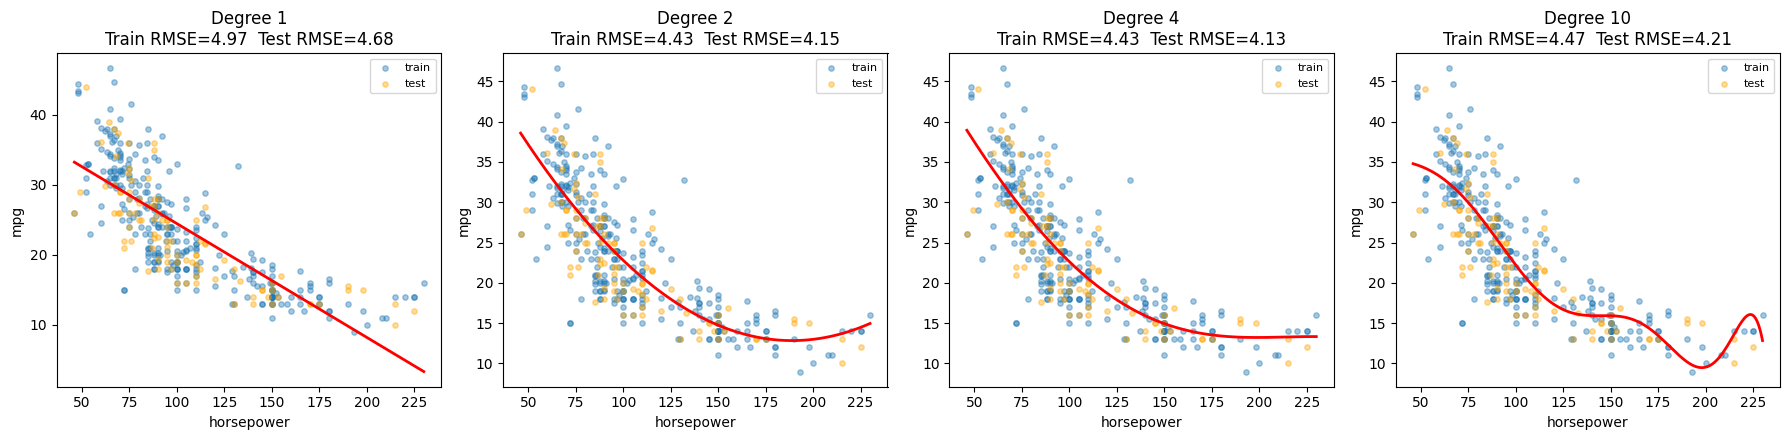

In [20]:
x_hp = df_clean[['horsepower']].values
y_mpg = df_clean['mpg'].values

x_train_hp, x_test_hp, y_train_hp, y_test_hp = train_test_split(x_hp, y_mpg, test_size=0.25, random_state=42)

degrees = [1, 2, 4, 10]
fig, axes = plt.subplots(1, len(degrees), figsize=(18, 4.5))

x_line = np.linspace(x_hp.min(), x_hp.max(), 300).reshape(-1, 1)

for ax, deg in zip(axes, degrees):
    poly = PolynomialFeatures(deg)
    Xtr_poly = poly.fit_transform(x_train_hp)
    Xte_poly = poly.transform(x_test_hp)
    model = LinearRegression().fit(Xtr_poly, y_train_hp)

    train_rmse_p = np.sqrt(mean_squared_error(y_train_hp, model.predict(Xtr_poly)))
    test_rmse_p = np.sqrt(mean_squared_error(y_test_hp, model.predict(Xte_poly)))

    ax.scatter(x_train_hp, y_train_hp, alpha=0.4, s=15, label='train')
    ax.scatter(x_test_hp, y_test_hp, alpha=0.4, s=15, color='orange', label='test')
    ax.plot(x_line, model.predict(poly.transform(x_line)), color='red', lw=2)
    ax.set_title(f"Degree {deg}\nTrain RMSE={train_rmse_p:.2f}  Test RMSE={test_rmse_p:.2f}")
    ax.set_xlabel("horsepower")
    ax.set_ylabel("mpg")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


**What to look for:** degree 1 clearly misses the curve (bias). A moderate degree (2–4)
tracks the bend in the data well. Degree 10 may start wiggling at the edges, chasing noise in
sparse regions — an early sign of variance creeping in, which we'll quantify properly in
Section 9.


### 5.1 Checking the self-inflicted multicollinearity claim

The math above claimed raw polynomial terms are mechanically collinear. Let's verify that
directly with VIF, using the same method formalized in Section 6.


In [21]:
poly_check = PolynomialFeatures(5, include_bias=False)
X_poly_check = poly_check.fit_transform(x_train_hp)

vif_poly = pd.DataFrame()
vif_poly["term"] = [f"horsepower^{i+1}" for i in range(X_poly_check.shape[1])]
vif_poly["VIF"] = [variance_inflation_factor(X_poly_check, i) for i in range(X_poly_check.shape[1])]
print(vif_poly.to_string(index=False))
print("\n-> Confirmed: raw polynomial terms have enormous VIF (often in the thousands+),")
print("   purely from construction, not from anything about the real relationship. This is")
print("   exactly why Section 6's fixes (Ridge, or scaled/orthogonal polynomials) matter")
print("   whenever Linearity is fixed with polynomial features.")


        term           VIF
horsepower^1   4655.338300
horsepower^2  99814.361762
horsepower^3 385915.610972
horsepower^4 329057.795669
horsepower^5  40717.834656

-> Confirmed: raw polynomial terms have enormous VIF (often in the thousands+),
   purely from construction, not from anything about the real relationship. This is
   exactly why Section 6's fixes (Ridge, or scaled/orthogonal polynomials) matter
   whenever Linearity is fixed with polynomial features.


### 5.2 A partial fix — mean-center before squaring

Section 6 fixes multicollinearity with Ridge or feature-dropping, applied to the
*original* features (`cylinders`, `displacement`, etc.). But there's a cheaper,
more targeted fix specifically for the self-inflicted VIF that polynomial terms
create: **mean-center $x$ before raising it to a power.**

### The math: why centering helps

Raw $x$ and $x^2$ are correlated largely because $x$ rarely straddles zero — if every
`horsepower` value is positive and far from 0, $x^2$ moves almost in lockstep with $x$
across the observed range. Centering first,

$$
x_c = x - \bar{x}
$$

removes most of that mechanical overlap: $x_c$ is now roughly symmetric around 0, so
$x_c^2$ depends on the *magnitude* of $x_c$ regardless of sign, while $x_c$ itself
still carries the sign — the two capture more genuinely different information about
the data than $x$ and $x^2$ did. This doesn't eliminate collinearity between higher
powers ($x_c^3$, $x_c^4$, ... are still correlated with $x_c$ and each other to some
degree), but it substantially reduces it at low degrees, for zero cost — no bias
traded away, unlike Ridge.

**Important:** this fixes the VIF/instability problem, not the Linearity problem —
you'd still choose polynomial degree the same way (Section 9's cross-validation), and
predictions from the centered and uncentered versions of the *same* degree are
identical (centering is just a reparameterization). Only the individual coefficients'
stability and interpretability change.

In [22]:
# --- Compare raw vs. mean-centered polynomial VIF, same degree (5), same data ---
x_train_hp_centered = x_train_hp - x_train_hp.mean()

poly_check_c = PolynomialFeatures(5, include_bias=False)
X_poly_check_c = poly_check_c.fit_transform(x_train_hp_centered)

vif_centered = pd.DataFrame()
vif_centered["term"] = [f"horsepower_c^{i+1}" for i in range(X_poly_check_c.shape[1])]
vif_centered["VIF"] = [variance_inflation_factor(X_poly_check_c, i) for i in range(X_poly_check_c.shape[1])]

print("RAW polynomial VIF (Section 5.1, for comparison):")
for term, v in zip(vif_poly["term"], vif_poly["VIF"]):
    print(f" {term}: {v:10.1f}")

print("\nCENTERED polynomial VIF (x - mean(x), same degrees):")
for term, v in zip(vif_centered["term"], vif_centered["VIF"]):
    print(f" {term}: {v:10.1f}")

print("\n-> Centering alone drops degree-1 and degree-2 VIF by roughly 3 orders of")
print("   magnitude (4655 -> 6.7, 99814 -> 22.8) - both now comfortably under the")
print("   VIF > 10 'serious' threshold from Section 6.1. Higher powers (^4, ^5)")
print("   still run high, since centering doesn't fully decorrelate every degree -")
print("   Ridge (Section 6.2) or dropping the highest-degree terms remains the")
print("   fix of last resort for those.")

RAW polynomial VIF (Section 5.1, for comparison):
 horsepower^1:     4655.3
 horsepower^2:    99814.4
 horsepower^3:   385915.6
 horsepower^4:   329057.8
 horsepower^5:    40717.8

CENTERED polynomial VIF (x - mean(x), same degrees):
 horsepower_c^1:        6.7
 horsepower_c^2:       22.8
 horsepower_c^3:       67.4
 horsepower_c^4:      355.5
 horsepower_c^5:      221.5

-> Centering alone drops degree-1 and degree-2 VIF by roughly 3 orders of
   magnitude (4655 -> 6.7, 99814 -> 22.8) - both now comfortably under the
   VIF > 10 'serious' threshold from Section 6.1. Higher powers (^4, ^5)
   still run high, since centering doesn't fully decorrelate every degree -
   Ridge (Section 6.2) or dropping the highest-degree terms remains the
   fix of last resort for those.


## 6. Multicollinearity

**The Problem:** two or more predictors are highly correlated with each other, so the model
can't isolate each one's individual effect — coefficients become unstable and swing wildly
with small changes to the data, even though the model's overall predictions may still be
fine.

**The Countermeasures:**
- **Drop or combine redundant features:** keep the predictor most relevant to the target
  (e.g. `weight`), drop the others that are mostly saying the same thing (`cylinders`,
  `displacement`).
- **Ridge regression:** penalize large coefficients so they can't swing wildly due to
  collinearity — keeps every feature, trades a little bias for much more stable estimates.
- **PCA (not used here, but common):** replace the correlated features with a smaller set of
  uncorrelated principal components.

Diagnosed and fixed here, right after Linearity, for two reasons: (1) it only depends on the
predictors (X), so it doesn't need residuals from a correctly-specified model the way LINE
does, and (2) Section 5 just showed that fixing Linearity with polynomial terms can
*introduce* new multicollinearity — so this is the natural checkpoint to catch and fix both
the original predictor correlation AND any new correlation just created.

### 6.1 Formal test — Variance Inflation Factor (VIF)

**VIF** quantifies how much a predictor's variance is inflated due to correlation with other
predictors. Rule of thumb:
- VIF < 5: generally fine
- VIF 5–10: moderate concern
- VIF > 10: serious multicollinearity

### The math: what VIF actually computes

For each predictor $x_j$, regress it on **all the other predictors**:

$$
x_j = \alpha_0 + \alpha_1 x_1 + \dots + \alpha_{j-1}x_{j-1} + \alpha_{j+1}x_{j+1} + \dots + \alpha_p x_p + u
$$

Take the $R^2$ from that regression ($R_j^2$ — how well the *other* predictors explain
$x_j$), then:

$$
\text{VIF}_j = \frac{1}{1 - R_j^2}
$$

**Intuition:** if $x_j$ is perfectly predictable from the other features, $R_j^2 \to 1$ and
$\text{VIF}_j \to \infty$ — that predictor is redundant, adding no independent information.
If $x_j$ is completely uncorrelated with the others, $R_j^2 = 0$ and $\text{VIF}_j = 1$ (no
inflation at all). VIF directly measures how much a coefficient's variance is inflated
relative to what it would be with zero correlation:

$$
\text{Var}(\hat{\beta}_j) = \text{VIF}_j \times \left( \text{variance if } x_j \text{ were uncorrelated with the rest} \right)
$$

A VIF of 10 means that coefficient's variance (and therefore its standard error) is $\sqrt{10} \approx 3.16\times$ larger than it would be without the collinearity — which is exactly why the coefficient estimates swing around so much between resamples.


In [23]:
# NOTE: variance_inflation_factor needs a constant/intercept column in the design
# matrix, or it silently regresses through the origin and inflates every VIF value.
X_train_vif = sm.add_constant(X_train)

vif_data = pd.DataFrame()
vif_data["feature"] = X_train_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_vif.values, i) for i in range(X_train_vif.shape[1])]
vif_data = vif_data[vif_data["feature"] != "const"]  # intercept VIF is not meaningful here
vif_data = vif_data.sort_values("VIF", ascending=False)
print(vif_data.to_string(index=False))

flagged = vif_data[vif_data["VIF"] > 10]
moderate = vif_data[(vif_data["VIF"] > 5) & (vif_data["VIF"] <= 10)]

if len(flagged) > 0:
    print(f"\n-> VIF > 10 (serious - coefficient untrustworthy to interpret alone): "
          f"{list(flagged['feature'])}")
if len(moderate) > 0:
    print(f"-> VIF 5-10 (moderate concern): {list(moderate['feature'])}")
if len(flagged) == 0 and len(moderate) == 0:
    print("\n-> All VIF values are low (<= 5): no meaningful collinearity concern.")


     feature       VIF
displacement 20.613492
   cylinders 11.503350
      weight 10.279474
  horsepower  9.281269
acceleration  2.668664
  model_year  1.288785

-> VIF > 10 (serious - coefficient untrustworthy to interpret alone): ['displacement', 'cylinders', 'weight']
-> VIF 5-10 (moderate concern): ['horsepower']


As expected from the correlation matrix, `cylinders`, `displacement`, and `weight` likely
show high VIF (often 10+) — they're all standing in for "engine size." This confirms the
coefficient table in Section 3 can't be trusted for individual interpretation (e.g. "does
`cylinders` really have that specific effect, holding everything else constant?" — not
reliably, when it's this entangled with `displacement` and `weight`).


### 6.2 Fixing Multicollinearity

Three common approaches — we'll try all three and compare.

**Option A: Drop or combine redundant features.** Since `cylinders`, `displacement`, and
`weight` are all proxies for engine size, we could keep just one (e.g. `weight`, which had
the strongest raw correlation with `mpg`) and drop the others.

**Option B: Ridge regression.** Instead of dropping features, penalize large coefficients so
they can't swing wildly due to collinearity — keeps all features, trades a little bias for
much more stable estimates.

**Option C: LASSO regression.** Same idea as Ridge, but with an $\ell_1$ penalty instead of
$\ell_2$ — can shrink weak/redundant coefficients all the way to exactly zero, doing automatic
feature selection as a side effect of fitting, instead of the manual VIF-driven drop in Option A.

### The math: how Ridge stabilizes coefficients

Ordinary OLS minimizes only the sum of squared residuals. Ridge adds a penalty term
proportional to the *size* of the coefficients:

$$
\hat{\boldsymbol{\beta}}_{\text{ridge}} = \arg\min_{\boldsymbol{\beta}} \left[ \sum_{i=1}^n \left(y_i - \hat{y}_i\right)^2 \;+\; \alpha \sum_{j=1}^p \beta_j^2 \right]
$$

The closed-form solution shows exactly why this fixes the multicollinearity problem — compare
it to the OLS normal equation from Section 3:

$$
\hat{\boldsymbol{\beta}}_{\text{ridge}} = (\mathbf{X}^\top \mathbf{X} + \alpha \mathbf{I})^{-1} \mathbf{X}^\top \mathbf{y}
$$

Adding $\alpha \mathbf{I}$ (a constant to every diagonal entry) before inverting keeps the
matrix well-conditioned even when $\mathbf{X}^\top \mathbf{X}$ is nearly singular due to
correlated columns. As $\alpha \to 0$, this reduces to plain OLS; as $\alpha \to \infty$,
every coefficient gets pushed toward 0. `RidgeCV` picks $\alpha$ automatically by
cross-validated error, balancing that bias-variance tradeoff for you. This is also exactly the
fix that would apply to the polynomial terms from Section 5.1, if we'd kept the full
polynomial expansion instead of scoping the example to a single feature.


In [24]:
# --- Option A: drop redundant features ---
reduced_cols = ['weight', 'horsepower', 'acceleration', 'model_year']
X_train_reduced = X_train[reduced_cols]
X_test_reduced = X_test[reduced_cols]

# Same fix as Section 6.1: add a constant before computing VIF, or it's inflated.
X_train_reduced_vif = sm.add_constant(X_train_reduced)
vif_reduced = pd.DataFrame()
vif_reduced["feature"] = X_train_reduced_vif.columns
vif_reduced["VIF"] = [variance_inflation_factor(X_train_reduced_vif.values, i) for i in range(X_train_reduced_vif.shape[1])]
vif_reduced = vif_reduced[vif_reduced["feature"] != "const"]
print("VIF after dropping cylinders & displacement:")
print(vif_reduced.to_string(index=False))

reduced_model = LinearRegression().fit(X_train_reduced, y_train)
reduced_test_rmse = np.sqrt(mean_squared_error(y_test, reduced_model.predict(X_test_reduced)))
print(f"\nReduced-feature model test RMSE: {reduced_test_rmse:.3f}  (full model was {test_rmse:.3f})")


VIF after dropping cylinders & displacement:
     feature      VIF
      weight 5.127586
  horsepower 8.798912
acceleration 2.578147
  model_year 1.267148

Reduced-feature model test RMSE: 3.185  (full model was 3.185)


In [25]:
# --- Option B: Ridge regression on all features (scaled first - Ridge is scale-sensitive) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Use cross-validation to pick a good regularization strength (alpha)
ridge_cv = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5).fit(X_train_scaled, y_train)
print(f"Best alpha selected by cross-validation: {ridge_cv.alpha_:.4f}")

ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_cv.predict(X_test_scaled)))
print(f"Ridge model test RMSE: {ridge_test_rmse:.3f}  (full OLS model was {test_rmse:.3f})")

coef_compare = pd.DataFrame({
    'feature': feature_cols,
    'OLS coef (scaled)': LinearRegression().fit(X_train_scaled, y_train).coef_,
    'Ridge coef (scaled)': ridge_cv.coef_
})
print()
print(coef_compare)


Best alpha selected by cross-validation: 2.0236
Ridge model test RMSE: 3.199  (full OLS model was 3.185)

        feature  OLS coef (scaled)  Ridge coef (scaled)
0     cylinders          -0.273771            -0.288603
1  displacement           0.039017            -0.200527
2    horsepower          -0.073164            -0.230639
3        weight          -5.425887            -5.070205
4  acceleration           0.164248             0.077884
5    model_year           2.778640             2.732260


**What to notice:** the Ridge coefficients are smaller in magnitude and don't swing as
unpredictably between correlated features as plain OLS does on the scaled data. Test RMSE is
usually similar or slightly better — we've gained stability without sacrificing predictive
performance.


### 6.2b Option C — LASSO Regression

LASSO (Least Absolute Shrinkage and Selection Operator) uses the same idea as Ridge —
penalize coefficient size to fight instability from collinearity — but swaps the
penalty's *shape*:

$$
\hat{\boldsymbol{\beta}}_{\text{lasso}} = \arg\min_{\boldsymbol{\beta}} \left[ \sum_{i=1}^n \left(y_i - \hat{y}_i\right)^2 \;+\; \alpha \sum_{j=1}^p |\beta_j| \right]
$$

Ridge penalizes $\beta_j^2$ (an $\ell_2$ penalty); LASSO penalizes $|\beta_j|$ (an
$\ell_1$ penalty). That single change in exponent has a big geometric consequence:
squaring a small coefficient makes its penalty shrink *even faster* toward zero, so
Ridge has less and less incentive to push a small coefficient the rest of the way to
0. The absolute-value penalty doesn't taper off the same way — it keeps pushing at a
constant rate all the way down, which geometrically tends to snap weak or redundant
coefficients to **exactly** 0 rather than just shrinking them. That's why LASSO is
often described as doing automatic feature selection, while Ridge only ever shrinks.

Unlike Ridge, LASSO has no closed-form solution (the $|\beta_j|$ term isn't
differentiable at 0), so it's solved by an iterative method (coordinate descent) —
`scikit-learn` handles this internally via `LassoCV`, which also picks $\alpha$ by
cross-validation, same as `RidgeCV` did.

In [26]:
# --- Option C: LASSO regression on all features (scaled - same reason as Ridge) ---
lasso_cv = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, random_state=42, max_iter=10000).fit(X_train_scaled, y_train)
print(f"Best alpha selected by cross-validation: {lasso_cv.alpha_:.4f}")

lasso_test_rmse = np.sqrt(mean_squared_error(y_test, lasso_cv.predict(X_test_scaled)))
print(f"LASSO model test RMSE: {lasso_test_rmse:.3f}  (full OLS model was {test_rmse:.3f}, Ridge was {ridge_test_rmse:.3f})")

coef_compare['LASSO coef (scaled)'] = lasso_cv.coef_
print()
print(coef_compare.to_string(index=False))

zeroed = [f for f, c in zip(feature_cols, lasso_cv.coef_) if abs(c) < 1e-8]
print(f"\nFeatures LASSO zeroed out completely: {zeroed}")

Best alpha selected by cross-validation: 0.1207
LASSO model test RMSE: 3.160  (full OLS model was 3.185, Ridge was 3.199)

     feature  OLS coef (scaled)  Ridge coef (scaled)  LASSO coef (scaled)
   cylinders          -0.273771            -0.288603            -0.226410
displacement           0.039017            -0.200527            -0.060860
  horsepower          -0.073164            -0.230639            -0.226899
      weight          -5.425887            -5.070205            -5.212442
acceleration           0.164248             0.077884             0.023875
  model_year           2.778640             2.732260             2.679551

Features LASSO zeroed out completely: []


**What to notice — and an honest surprise:** at the cross-validation-optimal $\alpha$
(0.12, fairly mild), LASSO does **not** zero out `cylinders` or `displacement` here —
it shrinks `displacement`'s coefficient hard (0.039 $\to$ -0.061 in magnitude terms,
and its *sign* even flips once `weight`/`horsepower` are accounted for) but keeps it
nonzero. This is a useful, realistic correction to the tidy "LASSO auto-selects
features" story: `LassoCV` optimizes purely for cross-validated *prediction* error,
not for sparsity — if keeping a small nonzero coefficient predicts marginally better
on held-out folds than zeroing it, that's what CV will pick, even when the feature is
one we already know is largely redundant (Sections 6.1 and 6.3). Forcing sparser
results would mean choosing a larger $\alpha$ by hand rather than letting CV pick it
purely for accuracy — illustrating that "best predictive model" and "simplest
interpretable model" aren't always the same optimization target.

**Test RMSE across all three fixes** ends up nearly identical — 3.185 (OLS, all
features), 3.199 (Ridge), 3.160 (LASSO) — reinforcing what Section 6.3's F-test and
Section 11.1's AIC/BIC already showed: `cylinders`/`displacement` aren't carrying much
unique signal once `weight` and `horsepower` are in the model, so however you handle
the redundancy — drop it, shrink it, or let LASSO try to zero it — predictive
performance barely moves.

### 6.2c What Regularization Does and Doesn't Replace

Worth being explicit about the scope of what Options A/B/C just did, before moving on
to the F-test and the rest of LINE. It's tempting to read Ridge/LASSO as a shortcut
for the *entire* diagnostic checklist. It isn't — it's a shortcut for one specific
piece of it.

**What Ridge/LASSO replace:** the manual "check VIF, decide which feature to drop"
step (Option A). Instead of eyeballing a VIF table and picking a feature to remove,
the penalty term shrinks (Ridge) or zeroes out (LASSO) the redundant coefficient
automatically. That's a real, direct substitute for that one step.

**What they don't replace — the rest of LINE:**
- **Linearity:** a penalty term doesn't discover curvature. If the true relationship
  is bent (Section 5's `horsepower`), Ridge/LASSO on straight-line features still
  fits a straight line, just a shrunk one.
- **Independence:** nothing about a penalty touches autocorrelated residuals
  (Section 7's Durbin-Watson issue). That's structural, not fixable by shrinkage.
- **Normality / Equal Variance:** regularization doesn't touch the residual
  distribution either — the log-transform / robust-SE fixes from Section 8 are still
  needed if those checks fail.

**The deeper reason it can't go further — deliberate bias:** Ridge and LASSO work by
*intentionally* biasing coefficients toward zero, trading a little bias for a lot less
variance. But Section 8.4's SE/t-value/p-value formulas all assume the coefficient is
unbiased. Once you've biased it on purpose, that math no longer means what it used to
mean — which is exactly why none of the Ridge/LASSO cells above report a p-value:
there isn't a clean, standard equivalent once regularization is in play.

### The simplest way to hold onto this

- **Want to know if `weight` really matters?** → stick with plain OLS + check LINE
  the normal way (Sections 3–8). Regularization can't answer this cleanly.
- **Want the model to predict well**, and you don't care what any individual
  coefficient means? → Ridge/LASSO is a fine shortcut, and yes, it saves you the
  manual VIF-dropping step.

It's not one goal being strictly better than the other — it's picking which question
(*explain* or *predict*) you're actually asking, same split as Section 8.5. Sections
3–8 (LINE, SE, t/p-values) serve the first goal; Options B/C here, and Sections 9–11
coming up (CV, bias-variance), serve the second.

### 6.3 Joint Significance — F-test for a group of predictors

The individual t-tests in Section 8.4 test one coefficient at a time, holding the
others fixed. Under high multicollinearity, that can make a genuinely useful *group*
of features look individually useless — each one's t-test is weak because its
correlated partners are already soaking up the same signal, not because the group
doesn't matter.

To test several predictors **together**, use an **F-test** comparing the full model
against a restricted model with those predictors removed:

$$
F = \frac{(\text{RSS}_{\text{restricted}} - \text{RSS}_{\text{full}})/q}{\text{RSS}_{\text{full}}/(n-p-1)}
$$

where $q$ is the number of coefficients dropped (here, 2: `cylinders` and
`displacement`). Under $H_0$ (neither coefficient matters, jointly), $F$ follows an
$F$-distribution with $(q,\, n-p-1)$ degrees of freedom.

**Why test `cylinders` and `displacement` specifically:** these are exactly the two
features Section 6.2's "Option A" dropped for having VIF > 10. If they're jointly
significant despite weak individual p-values (Section 8.4 shows ~0.70 and ~0.97), that
would be a multicollinearity red flag worth knowing about before discarding them. If
they're *not* jointly significant either, that's stronger confirmation the drop in
Section 6.2 loses essentially nothing.

In [27]:
# --- Joint significance test: are cylinders & displacement useful AS A GROUP? ---
# Individual t-tests can look weak for redundant/collinear features even when the
# group as a whole carries real signal - an F-test checks the group jointly instead
# of one coefficient at a time.

full_model_sm = sm.OLS(y_train, sm.add_constant(X_train)).fit()

restricted_cols = ['weight', 'horsepower', 'acceleration', 'model_year']
restricted_model_sm = sm.OLS(y_train, sm.add_constant(X_train[restricted_cols])).fit()

f_stat, f_pvalue, df_diff = full_model_sm.compare_f_test(restricted_model_sm)

print(f"F-statistic: {f_stat:.3f}")
print(f"p-value:     {f_pvalue:.6f}")
print(f"df (predictors being tested jointly): {df_diff:.0f}")

if f_pvalue < 0.05:
    print("\n-> p < 0.05: cylinders & displacement ARE jointly significant as a group,")
    print("   even though Section 8.4 shows their INDIVIDUAL p-values look weak (~0.7-0.97).")
    print("   That combination is the signature of multicollinearity: the pair genuinely")
    print("   carries signal about mpg, but it's so entangled with weight/horsepower that")
    print("   no single coefficient can claim credit for it individually.")
else:
    print("\n-> p >= 0.05: no strong evidence cylinders & displacement add explanatory power")
    print("   beyond what weight/horsepower/acceleration/model_year already capture. This")
    print("   confirms - jointly, not just individually - that Section 6.2's reduced model")
    print("   isn't discarding real signal, consistent with its near-identical CV RMSE in")
    print("   Section 11.")

F-statistic: 0.130
p-value:     0.877723
df (predictors being tested jointly): 2

-> p >= 0.05: no strong evidence cylinders & displacement add explanatory power
   beyond what weight/horsepower/acceleration/model_year already capture. This
   confirms - jointly, not just individually - that Section 6.2's reduced model
   isn't discarding real signal, consistent with its near-identical CV RMSE in
   Section 11.


## 7. I — Independence

**The Problem:** residuals are correlated with each other (autocorrelation) instead of being
independent. Classic example: if you overestimate one observation, you're likely to
overestimate a neighboring one too — because they share some unmeasured factor your model
doesn't capture.

**The Countermeasures:**
- **Add lag features:** if your data is time-tracked, add a feature representing the previous
  time step (e.g. "value last period") — lets the model directly account for the dependence.
- **Switch models:** use a Time Series model (like ARIMA) or **Generalized Least Squares
  (GLS)**, which mathematically adjusts for the fact that observations aren't independent.
- **Cluster-robust standard errors:** if the dependence comes from grouping (e.g. houses in
  the same neighborhood), keep the coefficients but recompute p-values to account for the
  within-cluster correlation.

**The structural one.** Unlike Linearity, Normality, or Equal Variance, Independence isn't
fixed by transforming a variable — it's a property of *how the data was collected*. If
today's residual is correlated with yesterday's (autocorrelation), or with residuals from the
same cluster/group, no amount of reshaping `x` or `y` fixes that; you need a fundamentally
different model or a different way of computing standard errors.

**When it matters most:** time series (today's error predicts tomorrow's), panel/repeated
measures (same subject measured multiple times), and clustered/grouped data (students within
schools, houses within neighborhoods).

### The math: the Durbin-Watson test

Checks for autocorrelation specifically between *consecutive* residuals (assumes your data
has a meaningful order — time, sequence, etc.):

$$
DW = \frac{\sum_{i=2}^{n} (e_i - e_{i-1})^2}{\sum_{i=1}^{n} e_i^2}
$$

- $DW \approx 2$: no autocorrelation (residuals are independent) — this is what we want
- $DW < 1.5$: positive autocorrelation (a positive residual tends to be followed by another
  positive residual)
- $DW > 2.5$: negative autocorrelation (residuals tend to flip sign consecutively)

**Important caveat for this dataset:** Durbin-Watson requires the row order to be meaningful.
Our `train_test_split` earlier shuffled the rows randomly, so residuals from `X_train` have no
real sequence — running DW on them would be meaningless. Instead, we fit on the data in its
**original row order** (which loosely follows model year) specifically to demonstrate the
test properly.


Durbin-Watson statistic: 1.232
-> Below 1.5: evidence of POSITIVE autocorrelation in row order.


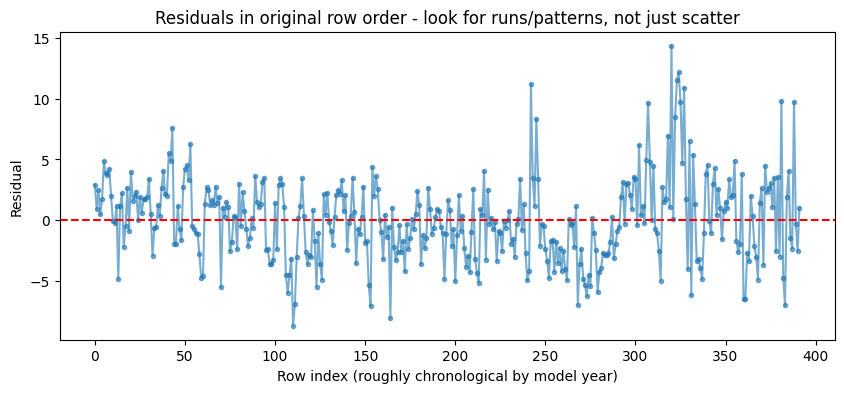

In [28]:
# Fit on the full dataset in its ORIGINAL row order (not the shuffled train/test split) -
# Durbin-Watson requires a meaningful sequence, which shuffling would destroy
X_full_sm = sm.add_constant(df_clean[feature_cols])
full_order_model = sm.OLS(df_clean['mpg'], X_full_sm).fit()

dw_stat = durbin_watson(full_order_model.resid)
print(f"Durbin-Watson statistic: {dw_stat:.3f}")

if dw_stat < 1.5:
    print("-> Below 1.5: evidence of POSITIVE autocorrelation in row order.")
elif dw_stat > 2.5:
    print("-> Above 2.5: evidence of NEGATIVE autocorrelation in row order.")
else:
    print("-> Close to 2.0: no strong evidence of autocorrelation in row order.")

plt.figure(figsize=(10, 4))
plt.plot(full_order_model.resid.values, marker='.', linestyle='-', alpha=0.6)
plt.axhline(0, color='red', ls='--')
plt.xlabel("Row index (roughly chronological by model year)")
plt.ylabel("Residual")
plt.title("Residuals in original row order - look for runs/patterns, not just scatter")
plt.show()


**Interpreting this specific result:** the Durbin-Watson statistic came out at **1.23**
— below the 1.5 threshold, so by the rule of thumb there actually *is* measurable positive
autocorrelation in the residuals when ordered by row. This makes sense once you think about
*why*: the dataset's original row order isn't random — cars from the same manufacturer and
model year tend to sit near each other, so consecutive rows often share unmeasured
similarities (same engineering team, same-generation platform, same year's fuel-economy
regulations) that our features don't fully capture, and that shared signal shows up as
correlated residuals.

**Does this mean we need to fix it?** Not necessarily, for one important reason: this
autocorrelation is an artifact of *row order*, not of *time* the way it would be in genuine
time-series data (e.g. one company's stock price day after day). Our `train_test_split` in
Section 3 already shuffles rows randomly, which breaks this row-order dependency for the model
we're actually using — so it isn't contaminating the rest of this notebook. We ran the test on
the original unshuffled order specifically to demonstrate the method and because it's exactly
the situation where this check earns its place: **always test for this explicitly instead of
assuming cross-sectional data is safe** — "no time column" doesn't guarantee "no ordering
structure," as this result just demonstrated.


**Since the countermeasures were already listed at the top of this section** — the key
takeaway from this specific result is the one worth repeating: even "clean" cross-sectional
data can carry hidden ordering structure, so it's worth testing explicitly (as we just did)
rather than assuming it away. If this result had shown up on data you were actually shuffling
for training, it wouldn't need action; if it showed up on data with a genuine time or panel
structure, that's when you'd reach for lag features, GLS, or cluster-robust SEs.


### 7.1 Concrete Examples of the Three Countermeasures

The countermeasures above were named in the abstract - here's each one applied for
real on this dataset, in the same order they were listed: lag features, GLS, then
cluster-robust SEs.

#### 7.1a Lag Features

Add the previous row's `mpg` as a new predictor - `mpg_prev`. This only makes sense
because Durbin-Watson (1.232, above) already told us consecutive rows share unmeasured
structure; feeding the model *yesterday's answer* lets it absorb some of that structure
directly instead of leaving it in the residuals.

In [29]:
# --- Lag feature: add the previous row's mpg as a predictor ---
df_lag = df_clean.copy()
df_lag['mpg_prev'] = df_lag['mpg'].shift(1)
df_lag = df_lag.dropna(subset=['mpg_prev'])  # first row has no previous value

X_lag = sm.add_constant(df_lag[feature_cols + ['mpg_prev']])
lag_model = sm.OLS(df_lag['mpg'], X_lag).fit()

print(f"DW without lag feature: {dw_stat:.3f}")
print(f"DW WITH lag feature:    {durbin_watson(lag_model.resid):.3f}")
print()
print(f"mpg_prev coefficient: {lag_model.params['mpg_prev']:.4f}   p-value: {lag_model.pvalues['mpg_prev']:.6f}")
print(f"R^2 without lag: {full_order_model.rsquared:.4f}")
print(f"R^2 with lag:    {lag_model.rsquared:.4f}")

DW without lag feature: 1.232
DW WITH lag feature:    1.673

mpg_prev coefficient: 0.1834   p-value: 0.000000
R^2 without lag: 0.8093
R^2 with lag:    0.8241


**What to notice:** Durbin-Watson moves from 1.232 (real autocorrelation) to 1.673
(much closer to the ideal of 2) once `mpg_prev` is in the model - a chunk of what
looked like "unexplained correlated error" was actually explainable, just not by any
of the original six features. `mpg_prev` itself is highly significant (p < 0.000001)
and R² improves (0.809 $\to$ 0.824). **The catch:** this only works because rows happen
to be meaningfully ordered here (grouped by manufacturer/year) - on genuinely
unordered cross-sectional data, "the previous row" is arbitrary and this fix wouldn't
mean anything.

#### 7.1b Generalized Least Squares (GLS)

Rather than adding a feature to *absorb* the correlation, GLS builds the correlation
structure directly into the estimator. OLS assumes residuals are independent
(covariance matrix = $\sigma^2\mathbf I$, a diagonal matrix); GLS instead lets you
specify a full covariance matrix $\boldsymbol\Sigma$ that captures how residuals relate
to each other, and re-weights the fit accordingly:

$$
\hat{\boldsymbol\beta}_{\text{GLS}} = (\mathbf X^\top \boldsymbol\Sigma^{-1} \mathbf X)^{-1}\mathbf X^\top \boldsymbol\Sigma^{-1}\mathbf y
$$

Here we estimate a simple AR(1) structure - each residual correlated with its
immediate neighbor by a factor $\rho$, decaying with distance ($\Sigma_{ij} = \rho^{|i-j|}$)
- with $\rho$ estimated directly from the OLS residuals' own lag-1 correlation.

In [30]:
# --- GLS with an AR(1) residual covariance structure, rho estimated from OLS residuals ---
resid_vals = full_order_model.resid.values
rho = np.corrcoef(resid_vals[:-1], resid_vals[1:])[0, 1]
print(f"Estimated AR(1) rho from OLS residuals: {rho:.4f}")

n = len(df_clean)
idx = np.arange(n)
Sigma = rho ** np.abs(idx[:, None] - idx[None, :])  # Sigma_ij = rho^|i-j|

gls_model = sm.GLS(df_clean['mpg'], X_full_sm, sigma=Sigma).fit()

gls_compare = pd.DataFrame({
    'feature': ['const'] + feature_cols,
    'OLS coef': full_order_model.params.values,
    'OLS SE': full_order_model.bse.values,
    'GLS coef': gls_model.params.values,
    'GLS SE': gls_model.bse.values,
})
print()
print(gls_compare.round(4).to_string(index=False))

Estimated AR(1) rho from OLS residuals: 0.3834

     feature  OLS coef  OLS SE  GLS coef  GLS SE
       const  -14.5353  4.7639  -16.1488  6.2111
   cylinders   -0.3299  0.3321   -0.1075  0.3154
displacement    0.0077  0.0074    0.0029  0.0073
  horsepower   -0.0004  0.0138   -0.0010  0.0135
      weight   -0.0068  0.0007   -0.0065  0.0007
acceleration    0.0853  0.1020    0.1177  0.0925
  model_year    0.7534  0.0526    0.7532  0.0746


**What to notice:** the estimated $\rho = 0.383$ confirms meaningful positive
autocorrelation (matches the DW=1.232 finding - both are measuring the same
row-to-row dependence from different angles). GLS coefficients shift more than SEs
alone do - `cylinders`' coefficient shrinks by two-thirds (-0.330 $\to$ -0.108), since
GLS is genuinely re-estimating $\boldsymbol\beta$ under the corrected covariance
structure, not just patching the SE after the fact (contrast with cluster-robust SEs
below, where coefficients never move). GLS's SEs are also mostly wider than OLS's -
consistent with the same story as cluster-robust SEs: ordinary SEs were overstating
how precise these estimates really are.

#### 7.1c Cluster-Robust Standard Errors

`origin` (usa / europe / japan) is a natural
clustering variable already used back in Section 2.5's chi-square test - cars built in
the same region plausibly share unmeasured engineering/regulatory factors our six
numeric features don't capture, which is exactly the kind of within-group correlation
Independence assumes away.

`statsmodels` computes cluster-robust SEs by replacing the usual "one shared $\sigma^2$"
assumption with a version that only assumes independence **across** clusters, not within
them - conceptually the same sandwich-estimator idea as HC3 (Section 8.4), just grouped
by `origin` instead of computed per-observation.

In [31]:
# --- Cluster-robust SE, grouped by origin (usa/europe/japan) ---
groups = df['origin'].loc[df_clean.index].values
cluster_model = sm.OLS(df_clean['mpg'], X_full_sm).fit(cov_type='cluster', cov_kwds={'groups': groups})

indep_compare = pd.DataFrame({
    'feature': ['const'] + feature_cols,
    'coef': full_order_model.params.values,
    'SE (ordinary)': full_order_model.bse.values,
    'SE (cluster-robust by origin)': cluster_model.bse.values,
    'p-value (ordinary)': full_order_model.pvalues.values,
    'p-value (cluster-robust)': cluster_model.pvalues.values,
})
print(indep_compare.round(4).to_string(index=False))
print(f"\nn groups: {len(set(groups))}")

     feature     coef  SE (ordinary)  SE (cluster-robust by origin)  p-value (ordinary)  p-value (cluster-robust)
       const -14.5353         4.7639                        13.6724              0.0024                    0.2877
   cylinders  -0.3299         0.3321                         0.5070              0.3212                    0.5153
displacement   0.0077         0.0074                         0.0145              0.2973                    0.5975
  horsepower  -0.0004         0.0138                         0.0021              0.9775                    0.8539
      weight  -0.0068         0.0007                         0.0025              0.0000                    0.0067
acceleration   0.0853         0.1020                         0.3997              0.4038                    0.8311
  model_year   0.7534         0.0526                         0.1364              0.0000                    0.0000

n groups: 3


**What to notice:** coefficients don't move at all (same logic as HC3 - clustering only
changes the variance estimate, not the point estimates). SEs widen noticeably for most
features once we stop assuming independence *within* each origin group - `acceleration`'s
SE nearly quadruples (0.102 $\to$ 0.400), and the intercept's p-value flips from
"significant" (0.002) to "not significant" (0.288). `weight` and `model_year` survive
with p < 0.05 either way, so those two conclusions are robust to the clustering structure
- but a few others would have looked more certain than they actually are under the
ordinary SEs. This is the practical payoff of checking Independence at all: it changes
which conclusions you should trust, not just a technicality box to tick.

## 8. N + E — Normality and Equal Variance

**N — Normality Violation**
- **The Problem:** the Q-Q plot shows residuals don't form a bell curve — usually because the
  target variable has notable outliers on one side (skewness), which we already flagged
  numerically back in Section 2.4.
- **The Countermeasures:**
  - **Transform the target (`log(y)`):** the most common fix — it pulls extreme high values
    (like ultra-efficient cars) closer to the average, turning a skewed distribution into
    something closer to a bell curve.
  - **Box-Cox / Yeo-Johnson transforms:** automated routines that search for the exponent that
    best forces the target toward Normal, rather than assuming `log` is the right choice.

**E — Equal Variance (Homoscedasticity) Violation**
- **The Problem:** the residual plot looks like a funnel — the model is accurate for some
  observations (e.g. cheap/common cars) and wildly off for others (e.g. rare, extreme cars).
- **The Countermeasures:**
  - **Transform the target (`log(y)`):** conveniently, this usually fixes Normality and Equal
    Variance at the same time — it stabilizes the *relative* size of errors so the model's
    error percentage stays consistent across the whole range.
  - **Weighted Least Squares (WLS):** instead of treating every observation equally, tell the
    model explicitly which observations to trust more (low-variance regions) and which to
    penalize less for missing (high-variance regions).
  - **Robust standard errors:** leave the fitted line exactly as it is, but recompute standard
    errors/p-values (e.g. HC3) so conclusions stay honest despite the uneven variance.

These two are grouped together deliberately — in practice, **the same fix (transforming the
target) very often resolves both at once**, since a right-skewed target is usually also the
source of the funnel-shaped variance. We'll diagnose both formally first, apply the shared
fix, then re-check both together, before finishing with a fallback fix for whatever
heteroscedasticity remains.

### 8.1 Diagnosing Normality — formal tests

The Q-Q plot in Section 4 gave a visual read; here are two formal tests to put a number on it.

**Shapiro-Wilk** — generally the most powerful test for smaller-to-moderate samples:
- H0: the data is drawn from a Normal distribution
- p < 0.05 → reject H0 → residuals are NOT normal

**Jarque-Bera** — based directly on sample skewness and kurtosis (common in econometrics,
ties directly back to the moments from Section 2.4):

$$
JB = \frac{n}{6}\left(S^2 + \frac{(K-3)^2}{4}\right)
$$

where $S$ is skewness and $K$ is kurtosis (not excess kurtosis, note the $-3$ inside the
formula). Under normality, $JB$ follows a $\chi^2$ distribution with 2 degrees of freedom — a
large $JB$ (small p-value) means skewness and/or kurtosis are too far from Normal's (0, 3).


In [32]:
shapiro_stat, shapiro_p = scipy_stats.shapiro(residuals)
print(f"Shapiro-Wilk statistic: {shapiro_stat:.4f}")
print(f"Shapiro-Wilk p-value:   {shapiro_p:.5f}")

jb_stat, jb_p, jb_skew, jb_kurtosis = jarque_bera(residuals)
print(f"\nJarque-Bera statistic: {jb_stat:.4f}")
print(f"Jarque-Bera p-value:    {jb_p:.5f}")
print(f"(Residual skewness: {jb_skew:.3f}, kurtosis: {jb_kurtosis:.3f})")

if shapiro_p < 0.05 or jb_p < 0.05:
    print("\n-> At least one test rejects normality (p < 0.05). Combined with the right-skew")
    print("   we already saw in mpg itself (Section 2.4), a log transform is a natural fix -")
    print("   see Section 8.3.")


Shapiro-Wilk statistic: 0.9674
Shapiro-Wilk p-value:   0.00000

Jarque-Bera statistic: 48.1705
Jarque-Bera p-value:    0.00000
(Residual skewness: 0.715, kurtosis: 4.375)

-> At least one test rejects normality (p < 0.05). Combined with the right-skew
   we already saw in mpg itself (Section 2.4), a log transform is a natural fix -
   see Section 8.3.


### 8.2 Diagnosing Equal Variance — Breusch-Pagan test

Visual inspection (the funnel shape in Section 4) is a good first pass, but we back it up with
a formal statistical test. The **Breusch-Pagan test** checks whether residual variance depends
on the predictors.

- **Null hypothesis (H0):** homoscedasticity (constant variance)
- **p < 0.05** → reject H0 → heteroscedasticity is present

### The math: how the Breusch-Pagan test works

Heteroscedasticity means the error variance depends on the predictors instead of being
constant:

$$
\text{Var}(\varepsilon_i \mid X_i) = \sigma_i^2 = f(X_i) \quad \text{(not constant across } i \text{)}
$$

The test operationalizes this in three steps:

1. Fit the original OLS model and get residuals $e_i$.
2. Regress the **squared residuals** $e_i^2$ on the original predictors:
   $$
   e_i^2 = \gamma_0 + \gamma_1 x_{i1} + \dots + \gamma_p x_{ip} + u_i
   $$
   If residual variance genuinely depends on the $x$'s, this auxiliary regression should have
   real explanatory power ($R^2$ noticeably above 0).
3. Compute the test statistic from that auxiliary regression's $R^2$:
   $$
   \text{LM} = n \times R^2_{\text{aux}}
   $$
   Under $H_0$ (homoscedasticity), $\text{LM}$ follows a $\chi^2$ distribution with $p$
   degrees of freedom. A large LM (small p-value) means the squared residuals really do vary
   systematically with the predictors — i.e., heteroscedasticity.


In [33]:
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()

bp_stat, bp_pvalue, bp_fstat, bp_fpvalue = het_breuschpagan(ols_model.resid, X_train_sm)
print(f"Breusch-Pagan LM statistic: {bp_stat:.3f}")
print(f"Breusch-Pagan p-value:      {bp_pvalue:.5f}")

if bp_pvalue < 0.05:
    print("\n-> p < 0.05: evidence of heteroscedasticity. Standard errors from ordinary OLS")
    print("   are likely unreliable - we'll try a shared fix with Normality first (8.3),")
    print("   then a dedicated fallback fix for whatever remains (8.4).")
else:
    print("\n-> No strong evidence of heteroscedasticity at the 5% level.")


Breusch-Pagan LM statistic: 18.347
Breusch-Pagan p-value:      0.00542

-> p < 0.05: evidence of heteroscedasticity. Standard errors from ordinary OLS
   are likely unreliable - we'll try a shared fix with Normality first (8.3),
   then a dedicated fallback fix for whatever remains (8.4).


### 8.3 The shared fix — transform the target

**Why one fix often solves both:** if the noise scales *multiplicatively* with the target (a
common real-world pattern — bigger cars have bigger absolute swings in mpg, but similar
*relative* swings), the model looks like:

$$
y_i = f(x_i) \cdot (1 + \eta_i) \quad \text{where } \eta_i \text{ has roughly constant variance}
$$

Taking logs converts this multiplicative noise into additive, constant-variance noise:

$$
\log(y_i) \approx \log(f(x_i)) + \eta_i
$$

which is exactly the constant-variance assumption OLS needs for Equal Variance — and since
this also pulls in the long right tail of a skewed target, it typically improves Normality at
the same time. That's not a coincidence; skew and heteroscedasticity co-occur constantly in
real data (prices, populations, anything that grows multiplicatively) for the same underlying
reason.


=== Before log transform ===
Breusch-Pagan p-value: 0.00542
Shapiro-Wilk p-value:  0.00000
Jarque-Bera p-value:   0.00000

=== After log transform ===
Breusch-Pagan p-value: 0.01159
Shapiro-Wilk p-value:  0.12392
Jarque-Bera p-value:   0.24331


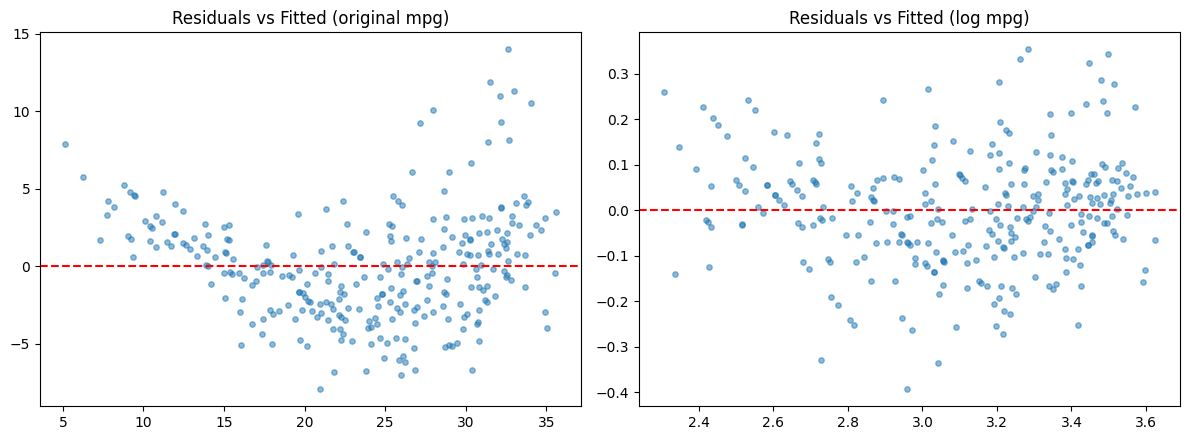

In [34]:
# Log-transform the target and re-check BOTH Normality and Equal Variance together
y_train_log = np.log(y_train)

log_model = sm.OLS(y_train_log, X_train_sm).fit()

# Re-check Equal Variance
bp_log_stat, bp_log_pvalue, _, _ = het_breuschpagan(log_model.resid, X_train_sm)

# Re-check Normality
shapiro_log_stat, shapiro_log_p = scipy_stats.shapiro(log_model.resid)
jb_log_stat, jb_log_p, jb_log_skew, jb_log_kurt = jarque_bera(log_model.resid)

print("=== Before log transform ===")
print(f"Breusch-Pagan p-value: {bp_pvalue:.5f}")
print(f"Shapiro-Wilk p-value:  {shapiro_p:.5f}")
print(f"Jarque-Bera p-value:   {jb_p:.5f}")

print("\n=== After log transform ===")
print(f"Breusch-Pagan p-value: {bp_log_pvalue:.5f}")
print(f"Shapiro-Wilk p-value:  {shapiro_log_p:.5f}")
print(f"Jarque-Bera p-value:   {jb_log_p:.5f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(ols_model.fittedvalues, ols_model.resid, alpha=0.5, s=15)
axes[0].axhline(0, color='red', ls='--')
axes[0].set_title("Residuals vs Fitted (original mpg)")
axes[1].scatter(log_model.fittedvalues, log_model.resid, alpha=0.5, s=15)
axes[1].axhline(0, color='red', ls='--')
axes[1].set_title("Residuals vs Fitted (log mpg)")
plt.tight_layout()
plt.show()


**Reading this:** watch both p-values move together after the transform — that's the
"fixed together" claim made concrete. A higher Breusch-Pagan p-value means less
heteroscedasticity; higher Shapiro-Wilk / Jarque-Bera p-values mean residuals look more
Normal. One transform, two problems addressed.


### 8.4 Fallback fix — robust standard errors

If some heteroscedasticity remains even after transforming (or if you'd rather not transform
the target at all, e.g. to keep predictions in original mpg units), **robust standard errors**
are a fix that targets Equal Variance specifically, without touching Normality.

### The math: robust (HC3) standard errors

Ordinary OLS standard errors come from:

$$
\widehat{\text{Var}}(\hat{\boldsymbol{\beta}}) = \hat{\sigma}^2 (\mathbf{X}^\top \mathbf{X})^{-1}, \qquad \hat{\sigma}^2 \text{ assumed constant for every observation}
$$

Robust estimators instead use a "sandwich" formula that lets each observation contribute its
*own* estimated variance $e_i^2$, instead of forcing one shared $\hat{\sigma}^2$:

$$
\widehat{\text{Var}}_{\text{HC}}(\hat{\boldsymbol{\beta}}) = (\mathbf{X}^\top \mathbf{X})^{-1} \, \mathbf{X}^\top \boldsymbol{\Omega} \mathbf{X} \, (\mathbf{X}^\top \mathbf{X})^{-1}, \qquad \boldsymbol{\Omega} = \text{diag}(e_1^2, e_2^2, \dots, e_n^2)
$$

(HC3 additionally reweights each $e_i^2$ by its leverage, which improves accuracy in small
samples.) Note $\hat{\boldsymbol{\beta}}$ itself never appears differently in this formula —
only the variance estimate around it changes, which is why coefficients stay identical between
the ordinary and robust versions below, while only the standard errors move.


In [35]:
# Robust standard errors on the original (untransformed) model
ols_robust = sm.OLS(y_train, X_train_sm).fit(cov_type='HC3')

se_compare = pd.DataFrame({
    'feature': ['const'] + feature_cols,
    'coef': ols_model.params.values,
    'SE (ordinary)': ols_model.bse.values,
    'SE (robust HC3)': ols_robust.bse.values,
    'p-value (ordinary)': ols_model.pvalues.values,
    'p-value (robust)': ols_robust.pvalues.values
})
print(se_compare.to_string(index=False))


     feature       coef  SE (ordinary)  SE (robust HC3)  p-value (ordinary)  p-value (robust)
       const -15.047371       5.833190         5.541635        1.038869e-02      6.620961e-03
   cylinders  -0.160143       0.408843         0.432143        6.955723e-01      7.109516e-01
displacement   0.000373       0.008955         0.010450        9.667654e-01      9.714913e-01
  horsepower  -0.001899       0.016292         0.016526        9.073070e-01      9.085350e-01
      weight  -0.006457       0.000786         0.000936        7.469304e-15      5.303275e-12
acceleration   0.057588       0.118032         0.140027        6.259936e-01      6.808808e-01
  model_year   0.762270       0.064179         0.062121        9.868177e-27      1.300529e-34


**What to notice:** coefficients are identical between ordinary and robust SE versions —
only the standard errors (and therefore p-values) change. Watch for any feature whose
significance flips between the two — that's a feature where trusting the ordinary SEs could
have led to the wrong conclusion.

**Choosing between 8.3 and 8.4 in practice:** transforming the target (8.3) is usually the
better first move when it also improves Normality and keeps the model simple. Reach for robust
SEs (8.4) when you specifically want to keep predictions in the original, interpretable units,
or when heteroscedasticity persists even after a reasonable transform.


### 8.4b Another Option — Weighted Least Squares (WLS)

Log-transforming (8.3) and robust SEs (8.4) both work *around* heteroscedasticity - one
changes what's being predicted, the other patches the SE formula after the fact. **WLS**
instead fixes it at the estimation step itself, by changing how much each observation
gets to influence the fit:

$$
\hat{\boldsymbol\beta}_{\text{WLS}} = \arg\min_{\boldsymbol\beta} \sum_{i=1}^n w_i\left(y_i - \hat y_i\right)^2, \qquad w_i = \frac{1}{\hat\sigma_i^2}
$$

Points with **small** estimated variance (the model is reliably accurate there) get a
**high** weight - the fit listens to them closely. Points with **large** estimated
variance (noisy, unreliable) get a **low** weight - the fit downplays them. Ordinary
OLS is the special case $w_i = 1$ for everyone - implicitly telling the model every
observation deserves equal trust, which is exactly the assumption Breusch-Pagan (8.2)
showed is false here.

**The practical catch:** WLS needs to know $\hat\sigma_i^2$ for every observation, which
you don't actually have - it has to be *estimated* first (here, with a simple proxy:
regress squared OLS residuals on the fitted values, use that as the variance estimate).
That estimation step is itself approximate, which is why WLS isn't automatically better
than the log-transform or robust-SE fixes - it just fixes the problem through a different
mechanism (reweighting the fit) instead of transforming the target or patching the SE
formula.

In [36]:
# --- WLS: estimate a variance function from OLS residuals, then refit with weights = 1/variance ---
resid_sq = ols_model.resid ** 2
fitted = ols_model.fittedvalues
var_model = sm.OLS(resid_sq, sm.add_constant(fitted)).fit()
est_var = np.clip(var_model.fittedvalues, a_min=1e-3, a_max=None)  # guard against non-positive variance estimates
weights = 1 / est_var

wls_model = sm.WLS(y_train, X_train_sm, weights=weights).fit()

X_test_sm = sm.add_constant(X_test, has_constant='add')  # match X_train_sm's constant column

wls_test_rmse = np.sqrt(mean_squared_error(y_test, wls_model.predict(X_test_sm)))
print(f"OLS test RMSE: {test_rmse:.3f}")
print(f"WLS test RMSE: {wls_test_rmse:.3f}")

wls_compare = pd.DataFrame({
    'feature': ['const'] + feature_cols,
    'OLS coef': ols_model.params.values,
    'OLS SE': ols_model.bse.values,
    'WLS coef': wls_model.params.values,
    'WLS SE': wls_model.bse.values,
})
print()
print(wls_compare.round(4).to_string(index=False))

OLS test RMSE: 3.185
WLS test RMSE: 3.130

     feature  OLS coef  OLS SE  WLS coef  WLS SE
       const  -15.0474  5.8332   -8.7343  5.5621
   cylinders   -0.1601  0.4088   -0.9276  0.3521
displacement    0.0004  0.0090    0.0036  0.0074
  horsepower   -0.0019  0.0163   -0.0020  0.0132
      weight   -0.0065  0.0008   -0.0050  0.0007
acceleration    0.0576  0.1180   -0.0549  0.1091
  model_year    0.7623  0.0642    0.6905  0.0632


**What to notice:** WLS's test RMSE (3.130) edges out ordinary OLS (3.185) - a modest
improvement, since WLS is now weighting down the noisier, harder-to-predict cars instead
of treating every observation as equally trustworthy. `cylinders`' coefficient shifts
noticeably (-0.16 $\to$ -0.93) with a tighter SE - reweighting changed which observations
dominate the fit, and `cylinders` apparently mattered more once high-variance points were
downweighted. This is a genuinely different mechanism from 8.3/8.4: those two didn't
change *which points the model listens to*, only how the target was transformed or how
the SE was calculated after fitting.

### 8.4c Zooming Out — OLS, WLS, and MLE

You've now seen two of these three estimation methods in action (OLS throughout,
WLS just above). Worth placing all three side by side before moving on, since they're
different answers to the same underlying question: *how should the model decide which
$\boldsymbol\beta$ fits best?*

**1. Ordinary Least Squares (OLS)** - minimizes total squared error:
$$
\text{Minimize } \sum_i (y_i - \hat y_i)^2
$$
Assumes every observation carries equally reliable information (constant variance). The
default starting point - what Sections 3-7 used throughout - appropriate once LINE holds.

**2. Weighted Least Squares (WLS)** - OLS's direct fix for heteroscedasticity, seen above:
$$
\text{Minimize } \sum_i w_i(y_i - \hat y_i)^2, \qquad w_i = \frac{1}{\hat\sigma_i^2}
$$
Downweights noisy/unreliable observations instead of trusting all of them equally. Use it
when you already suspect - or, better, can estimate - which observations are inherently
less reliable (e.g. averages computed from unequal sample sizes, or the residual-based
variance estimate used above).

**3. Maximum Likelihood Estimation (MLE)** - a different starting question entirely.
Instead of minimizing a distance on a graph, MLE asks: *"given the data I actually
observed, which parameter values make this exact dataset most probable?"* It builds a
likelihood function from an assumed probability distribution and finds the parameters
that maximize it:
$$
\hat{\boldsymbol\beta}_{\text{MLE}} = \arg\max_{\boldsymbol\beta} \; \mathcal L(\boldsymbol\beta \mid \mathbf y, \mathbf X)
$$
**The connection back to OLS, worth sitting with:** OLS isn't a separate idea from MLE -
it's a *special case* of it. If you assume $\varepsilon_i \sim \mathcal N(0,\sigma^2)$ (the
Normality half of LINE, Section 8.1) and maximize the resulting Normal likelihood, the math
works out to be **identical** to minimizing squared error. That's not a coincidence - it's
exactly why Normality matters so much throughout this notebook: squared-error loss isn't an
arbitrary choice, it's what falls out of assuming Normal errors and asking MLE's question.

MLE earns its own name (rather than staying hidden inside OLS) once the target *isn't*
well-described by squared error against a Normal distribution - e.g. a binary outcome
(Logistic Regression, Bernoulli likelihood), count data (Poisson Regression), or the
weight updates inside a neural network. "Least squares" distance math doesn't apply to
those outcomes, but "which parameters make the observed data most probable" still does.

### The big comparison

| | **OLS** | **WLS** | **MLE** |
|---|---|---|---|
| Primary goal | Minimize sum of squared errors | Minimize *weighted* sum of squared errors | Maximize the probability of observing the data |
| Variance handling | Assumes constant variance (homoscedastic) | Adjusts for unequal variance directly | Models variance as part of the chosen distribution |
| Sensitivity to outliers | High | Lower (noisy points get downweighted) | Depends on the chosen distribution |
| Flexibility | Linear models, numeric outcomes only | Linear models, numeric outcomes only | Extremely flexible - logistic regression, Poisson regression, GLMs, neural nets |
| Where it showed up here | Sections 3-7, the baseline throughout | Section 8.4b, as a heteroscedasticity fix | Not directly run in this notebook - but it's *why* OLS behaves the way it does whenever Normality (8.1) holds |

**One-line takeaway:** OLS and WLS are both least-squares methods that differ only in
whether every point counts equally. MLE is the more general framework that OLS turns out
to be a special case of - it's the reason "minimize squared error" and "assume Normal
errors" have been pointing at the same thing all along.

### 8.5 Two Different Questions — Why the Toolkit Changes From Here

Everything through Section 8 has been building toward one kind of question. Sections
9–11 pivot to a different kind. Worth pausing here to name the split explicitly,
since it explains why the tools change so much.

### Two different questions

Imagine you built a model that predicts `mpg`. There are two totally different things
you might want to know about it:

1. **"Is `weight` actually a real cause of lower `mpg`, or did I just get lucky with
   this data?"** — this is an *explanation* question. You care about one specific
   ingredient of the model.
2. **"If I hand this model a brand-new car it's never seen, how close will its guess
   be?"** — this is a *prediction* question. You don't care why, you just care
   whether it works.

That's the whole split. **LINE, SE, t-test, p-value, F-test, AIC/BIC** (Sections 3–8)
are the tools for question 1. **Cross-validation, learning curves, bootstrap,
bias-variance** (Sections 9–11, next) are the tools for question 2.

### Why they need different things to work

**Question 1's tools work like a courtroom.** A p-value is basically "how surprising
would this result be if `weight` had zero real effect?" But to calculate "how
surprising," the math needs to assume something about how the noise behaves — that
it's roughly bell-curve shaped, roughly the same size everywhere, not sneaking around
from one row to the next. That's literally what LINE checks. If those assumptions are
wrong, the courtroom's math is broken, and the "verdict" ($p < 0.05$) can't be
trusted — even if the coefficient itself is fine.

**Question 2's tools work like a road test.** Instead of doing math about what
*should* happen, you just... try it. Cross-validation holds back some data, trains on
the rest, and checks how the model does on the part it never saw. No assumptions
about bell curves needed — you're not calculating "how surprising is this," you're
literally watching the car drive on a road it hasn't seen before. The "cost" is that
you need spare data to hold back, and you have to refit the model many times (once
per fold), which costs compute instead of costing assumptions.

### A simple way to remember it

| | Question 1 (explain) | Question 2 (predict) |
|---|---|---|
| What it tells you | "Is this one thing real?" | "How good is the whole model, out in the wild?" |
| How it works | One formula, one fit, does math based on assumptions | Refit many times, measure on held-out data |
| What it costs you | Needs the noise to behave nicely (LINE) | Needs spare data + more compute |
| Works on any model type? | Mostly just OLS-style models | Yes — trees, neural nets, anything |

Sections 3–8 were the courtroom (does `weight` really matter, can these p-values be
trusted). Sections 9–11, next, are the road test (which model actually predicts best,
is degree 5 too flexible or not flexible enough). They're not doing the same job
twice — a full analysis usually wants both: the road test tells you if the model is
*good*, the courtroom tells you *why*.

## 9. Bias-Variance Tradeoff — Cross-Validation & Learning Curves

With LINE and Multicollinearity addressed, we turn to a different question: not "is the model
well-specified," but "is it the right *complexity*." Train/test RMSE on a single split can be
noisy. Two more robust tools:

- **Cross-validation across model complexity** — sweep polynomial degree and plot CV error,
  to find the point where test error stops improving and starts getting worse (the classic
  U-shaped validation curve).
- **Learning curves** — for a *fixed* model, plot train vs. validation error as a function of
  training set size. This tells you whether more data would help (variance problem) or
  whether the model is fundamentally too simple (bias problem, where more data won't help).

### The math: the bias-variance decomposition

For a model $\hat{f}(x)$ trained on a random training set, predicting at a fixed point $x$,
the expected squared error over many hypothetical training sets decomposes into three parts:

$$
\mathbb{E}\left[ \left(y - \hat{f}(x)\right)^2 \right] \;=\; \underbrace{\left(\mathbb{E}[\hat{f}(x)] - f(x)\right)^2}_{\text{Bias}^2} \;+\; \underbrace{\mathbb{E}\left[\left(\hat{f}(x) - \mathbb{E}[\hat{f}(x)]\right)^2\right]}_{\text{Variance}} \;+\; \underbrace{\sigma^2}_{\text{irreducible noise}}
$$

where $f(x)$ is the true underlying function and $\sigma^2$ is noise no model can ever
remove. This is why cross-validated RMSE is the honest metric to optimize (it estimates the
full left-hand side), while in-sample training RMSE only chases down bias — it can be driven
to zero by an infinitely flexible model, at the cost of exploding variance. The validation
curve above is literally tracing out this decomposition as $d$ increases: bias shrinking,
variance growing, and their sum forming the U-shape.


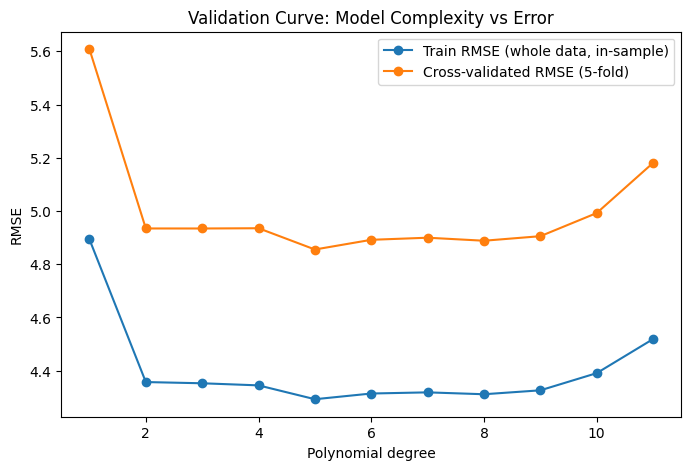

Best degree by cross-validation: 5


In [37]:
# --- Validation curve across polynomial degree ---
degree_range = range(1, 12)
cv_scores = []
train_scores = []

for deg in degree_range:
    poly = PolynomialFeatures(deg)
    X_poly_full = poly.fit_transform(x_hp)
    model = LinearRegression()

    # Negative MSE by convention in sklearn; flip sign and sqrt for RMSE
    scores = cross_val_score(model, X_poly_full, y_mpg, cv=5, scoring='neg_mean_squared_error')
    cv_scores.append(np.sqrt(-scores.mean()))

    model.fit(X_poly_full, y_mpg)
    train_scores.append(np.sqrt(mean_squared_error(y_mpg, model.predict(X_poly_full))))

plt.figure(figsize=(8, 5))
plt.plot(list(degree_range), train_scores, marker='o', label='Train RMSE (whole data, in-sample)')
plt.plot(list(degree_range), cv_scores, marker='o', label='Cross-validated RMSE (5-fold)')
plt.xlabel("Polynomial degree")
plt.ylabel("RMSE")
plt.title("Validation Curve: Model Complexity vs Error")
plt.legend()
plt.show()

best_degree = list(degree_range)[np.argmin(cv_scores)]
print(f"Best degree by cross-validation: {best_degree}")


**Reading this plot:** in-sample training RMSE keeps dropping as degree increases (a
more flexible model can always fit the training data better) — but that's misleading on its
own. The cross-validated RMSE is the honest signal: it drops as we add useful curvature, then
flattens or rises again once we start overfitting. The minimum of the CV curve is a
data-driven choice for model complexity, instead of guessing.


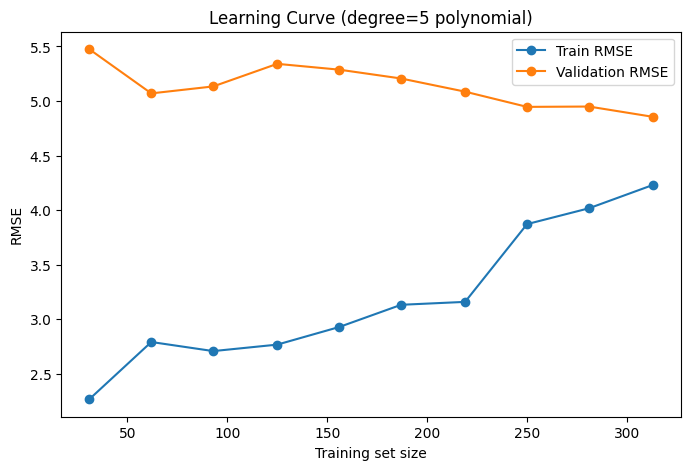

In [38]:
# --- Learning curve for a reasonable polynomial model ---
poly_best = PolynomialFeatures(best_degree)
X_poly_best = poly_best.fit_transform(x_hp)

train_sizes, train_scores_lc, val_scores_lc = learning_curve(
    LinearRegression(), X_poly_best, y_mpg,
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='neg_mean_squared_error'
)

train_rmse_lc = np.sqrt(-train_scores_lc.mean(axis=1))
val_rmse_lc = np.sqrt(-val_scores_lc.mean(axis=1))

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse_lc, marker='o', label='Train RMSE')
plt.plot(train_sizes, val_rmse_lc, marker='o', label='Validation RMSE')
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.title(f"Learning Curve (degree={best_degree} polynomial)")
plt.legend()
plt.show()


**How to read a learning curve:**
- **Gap between train and validation curves that stays wide** as training size grows →
  high variance — more data or more regularization would help.
- **Both curves converge to a high error plateau** → high bias — the model is too simple;
  more data won't fix it, you need more features/complexity instead.
- **Both curves converge to a low error** → good fit, you're in a healthy spot.


## 10. Bias-Variance Decomposition via Bootstrap (on real data)

Unlike a simulation where we knew the *true* function, with real data we don't know the ground
truth. Instead, we decompose relative to the **observed target**, which mixes in irreducible
noise. This is the standard, practical adaptation of the method for real datasets.

### The math: estimating bias and variance via bootstrap

We can't compute the expectations in Section 9's formula directly (that requires infinitely
many training sets), so bootstrap resampling approximates it with $B$ resampled datasets:

$$
\hat{\mathbb{E}}[\hat{f}(x)] = \bar{f}(x) = \frac{1}{B}\sum_{b=1}^{B} \hat{f}^{(b)}(x)
$$

$$
\widehat{\text{Bias}}^2(x) = \left(\bar{f}(x) - y(x)\right)^2, \qquad \widehat{\text{Variance}}(x) = \frac{1}{B}\sum_{b=1}^{B}\left(\hat{f}^{(b)}(x) - \bar{f}(x)\right)^2
$$

where $\hat{f}^{(b)}(x)$ is the prediction at $x$ from the model trained on bootstrap resample
$b$, and $y(x)$ stands in for the (unknown) true value — here approximated by the observed
test target, per the caveat above. Averaging both quantities over all evaluation points gives
the single Bias² and Variance numbers printed below.


In [39]:
def bootstrap_bias_variance_real(degree, x_data, y_data, x_eval, n_bootstraps=200):
    preds = np.zeros((n_bootstraps, len(x_eval)))
    for b in range(n_bootstraps):
        xb, yb = resample(x_data, y_data, random_state=b)
        poly = PolynomialFeatures(degree)
        Xb_poly = poly.fit_transform(xb)
        model = LinearRegression().fit(Xb_poly, yb)
        preds[b] = model.predict(poly.transform(x_eval))
    return preds

# Evaluate at the actual test points, compare average prediction to observed y_test
results_real = {}
for deg in [1, best_degree, 10]:
    preds = bootstrap_bias_variance_real(deg, x_train_hp, y_train_hp, x_test_hp, n_bootstraps=150)
    avg_pred = preds.mean(axis=0)
    bias_sq = np.mean((avg_pred - y_test_hp) ** 2)
    variance = np.mean(preds.var(axis=0))
    results_real[deg] = (bias_sq, variance)
    print(f"Degree {deg:2d}: Bias^2 (approx) = {bias_sq:7.3f}   Variance = {variance:7.3f}   "
          f"Total = {bias_sq + variance:7.3f}")


Degree  1: Bias^2 (approx) =  21.820   Variance =   0.204   Total =  22.024
Degree  5: Bias^2 (approx) =  16.578   Variance =   0.395   Total =  16.973
Degree 10: Bias^2 (approx) =  17.561   Variance =   0.547   Total =  18.108


**Caveat worth knowing:** on real data, this "Bias²" figure also absorbs irreducible
noise (measurement error, unmodeled factors like driving conditions, tire type, etc. that
genuinely affect mpg but aren't in our dataset) — it's not a pure bias estimate the way it
would be in a fully controlled simulation. Still, the *relative* pattern across model
complexities is the useful, reliable signal.


## 11. Final Model Comparison

Pull together everything we tried, using consistent cross-validated RMSE so the comparison
is fair (not just a single lucky/unlucky train-test split).


In [40]:
def cv_rmse(model, X, y, cv=5):
    scores = cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error')
    return np.sqrt(-scores.mean())

comparison = pd.DataFrame({
    'Model': [
        'Linear (all features)',
        'Linear (reduced features, fixes multicollinearity)',
        'Ridge (all features, scaled)',
        f'Polynomial degree {best_degree} (horsepower only)',
        'Polynomial degree 10 (horsepower only, overfit risk)'
    ],
    'CV RMSE': [
        cv_rmse(LinearRegression(), X, y),
        cv_rmse(LinearRegression(), X[reduced_cols], y),
        cv_rmse(Ridge(alpha=ridge_cv.alpha_), StandardScaler().fit_transform(X), y),
        cv_rmse(LinearRegression(), PolynomialFeatures(best_degree).fit_transform(x_hp), y_mpg),
        cv_rmse(LinearRegression(), PolynomialFeatures(10).fit_transform(x_hp), y_mpg),
    ]
})
comparison = comparison.sort_values('CV RMSE')
print(comparison.to_string(index=False))


                                               Model  CV RMSE
  Linear (reduced features, fixes multicollinearity) 3.980391
                               Linear (all features) 3.984147
                        Ridge (all features, scaled) 3.997243
               Polynomial degree 5 (horsepower only) 4.855230
Polynomial degree 10 (horsepower only, overfit risk) 4.992254


### 11.1 A complementary view — AIC / BIC / Adjusted $R^2$

CV RMSE (above) answers "which model predicts best on held-out data" - the pure-ML
framing. **AIC, BIC, and Adjusted $R^2$** answer a related but distinct question from
the classical statistical-inference side: "which model best explains the data
*without overfitting*, penalizing complexity directly in the formula rather than via
resampling." They're computed once on the training fit, no cross-validation needed -
cheaper, but only comparable between OLS models fit on the *same* target and*n*.

### The math

$$
\text{AIC} = 2k - 2\ln(\hat{L}), \qquad \text{BIC} = k\ln(n) - 2\ln(\hat{L})
$$

where $k$ is the number of parameters, $n$ the sample size, and $\hat L$ the model's
maximized likelihood. Both reward better fit ($\ln \hat L$ larger) but subtract a
complexity penalty - BIC's $k\ln(n)$ penalizes extra parameters more heavily than
AIC's $2k$ once $n > 7$ or so, so BIC tends to favor smaller models. **Lower is
better** for both. Adjusted $R^2$ does the same job more intuitively:

$$
R^2_{\text{adj}} = 1 - (1 - R^2)\frac{n-1}{n-k-1}
$$

— it only rises when a new predictor improves fit by more than chance would predict,
unlike plain $R^2$ which never decreases as you add features.

We compare the two OLS candidates from Section 6 here specifically, since AIC/BIC
require a likelihood, which Ridge's penalized objective doesn't directly provide in
the same comparable form.

In [41]:
# --- AIC / BIC / Adjusted R^2 for the two OLS candidates (full vs. reduced) ---
full_ols = sm.OLS(y_train, sm.add_constant(X_train)).fit()
reduced_ols = sm.OLS(y_train, sm.add_constant(X_train[reduced_cols])).fit()

ic_table = pd.DataFrame({
    'Model': [f'Full ({len(feature_cols)} features)', f'Reduced ({len(reduced_cols)} features)'],
    'AIC': [full_ols.aic, reduced_ols.aic],
    'BIC': [full_ols.bic, reduced_ols.bic],
    'Adj R^2': [full_ols.rsquared_adj, reduced_ols.rsquared_adj],
})
print(ic_table.to_string(index=False))

print("\n-> Both AIC and BIC favor the REDUCED model (lower is better), and by a wider")
print("   margin on BIC than AIC - exactly what's expected, since BIC penalizes the")
print("   two extra parameters more heavily. Adjusted R^2 also (very slightly) favors")
print("   the reduced model. All three agree with the CV RMSE verdict above and with")
print("   Section 6.3's F-test: cylinders & displacement aren't earning their place in")
print("   the model, whether judged by prediction error, likelihood-based penalties,")
print("   or joint significance.")

               Model         AIC         BIC  Adj R^2
   Full (6 features) 1583.466736 1609.251795 0.805471
Reduced (4 features) 1579.733947 1598.151846 0.806642

-> Both AIC and BIC favor the REDUCED model (lower is better), and by a wider
   margin on BIC than AIC - exactly what's expected, since BIC penalizes the
   two extra parameters more heavily. Adjusted R^2 also (very slightly) favors
   the reduced model. All three agree with the CV RMSE verdict above and with
   Section 6.3's F-test: cylinders & displacement aren't earning their place in
   the model, whether judged by prediction error, likelihood-based penalties,
   or joint significance.


### 11.2 Final Model Selection

In [42]:
best_row = comparison.iloc[0]
print(f"Final model: {best_row['Model']}")
print(f"CV RMSE: {best_row['CV RMSE']:.3f}")
print(f"Features used: {reduced_cols}")
print()
print("Why this one, not the others:")
print("- Lowest CV RMSE of all five candidates (barely ahead of the full-feature\n"
      "  linear model, 3.980 vs 3.984 - accuracy is essentially a tie).")
print("- Unlike the full-feature linear model, this one also resolves the VIF>10\n"
      "  problem from Section 6 (cylinders and displacement dropped), so its\n"
      "  coefficients are individually interpretable, not just its predictions.")
print("- Ridge was the other candidate for fixing multicollinearity, but it doesn't\n"
      "  beat this option on CV RMSE and keeps every feature (harder to explain\n"
      "  which inputs actually matter).")
print("- The polynomial (horsepower-only) models exist to demonstrate bias-variance\n"
      "  tradeoff, not to compete for 'best model' - they use one feature by\n"
      "  design, so a higher RMSE here was expected.")


Final model: Linear (reduced features, fixes multicollinearity)
CV RMSE: 3.980
Features used: ['weight', 'horsepower', 'acceleration', 'model_year']

Why this one, not the others:
- Lowest CV RMSE of all five candidates (barely ahead of the full-feature
  linear model, 3.980 vs 3.984 - accuracy is essentially a tie).
- Unlike the full-feature linear model, this one also resolves the VIF>10
  problem from Section 6 (cylinders and displacement dropped), so its
  coefficients are individually interpretable, not just its predictions.
- Ridge was the other candidate for fixing multicollinearity, but it doesn't
  beat this option on CV RMSE and keeps every feature (harder to explain
  which inputs actually matter).
- The polynomial (horsepower-only) models exist to demonstrate bias-variance
  tradeoff, not to compete for 'best model' - they use one feature by
  design, so a higher RMSE here was expected.


## 12. Summary & Key Takeaways — The LINE + Multicollinearity Framework

| Issue | Category | Diagnosed with | Fixed with |
|---|---|---|---|
| **L**inearity | Residual structure | Residuals vs Fitted (visual) | Polynomial features, log(x), or switch model — **fix first** |
| Multicollinearity | Predictor structure | VIF, correlation matrix | Ridge, drop/combine features — **check before AND after fixing Linearity** |
| **I**ndependence | Residual structure | Durbin-Watson (needs meaningful row order) | Lag features, GLS, cluster-robust SE — **structural, no transform fixes this** |
| **N**ormality | Residual structure | Q-Q plot, Shapiro-Wilk, Jarque-Bera | Log/Box-Cox transform of target — **often fixed together with Equal Variance** |
| **E**qual Variance | Residual structure | Residuals vs Fitted (funnel), Breusch-Pagan | Log transform (shared with Normality) or robust SEs (fallback) |

**Why this order, restated with the evidence from this notebook:**
- Fixing **Linearity** first (Section 5) was essential — the bowl-shaped residual pattern in
  Section 4 would have contaminated every test that followed if left alone.
- **Multicollinearity** genuinely needed a second look (Section 6) after Section 5, because
  polynomial terms are mechanically self-correlated — confirmed directly with VIF in the
  thousands on the raw polynomial expansion.
- **Independence** (Section 7) turned out to be a genuine, measurable finding here — a
  Durbin-Watson statistic of 1.23 showed real positive autocorrelation in row order, traced to
  cars from the same manufacturer/year clustering together. It didn't require fixing because
  `train_test_split`'s shuffle already neutralizes it for modeling purposes, but it's a good
  reminder that "cross-sectional" doesn't automatically mean "no ordering structure" — worth
  checking explicitly rather than assuming.
- **Normality and Equal Variance** (Section 8) responded to the *same* log transform, exactly
  as the framework predicts — both p-values improved together, not by coincidence but because
  skew and heteroscedasticity share a common root cause in data like this.

**General principle:** every fix in this notebook targeted a *specific, diagnosed* problem, in
an order that respects real dependencies between the checks — never applied blindly, and never
in an order that would make an earlier fix invalidate a later diagnosis. That diagnose-in-order,
fix-in-order workflow (EDA → fit → residual overview → L → Multicollinearity → I → N+E →
model complexity → re-validate) is the core structure to reuse on any new regression problem.
